# Task 4.3: Machine Learning Model Development for Move Tickers (Group)

## Group Information

Please enter your group details below:

**Group Name:** `6`  



This notebook guides you through Task 4.3, where you will design, implement, and validate machine learning models using financial time series data for Move Tickers.

You are encouraged to explore one or more of the following directions, depending on your project’s business problem: forecasting, classification, clustering, anomaly detection, or a hybrid approach.

📌 **Note:** This task is directly connected to your previously completed proposal and your database from Task 1.2.
---

## ⚠️ Important Note:


Do not change the order of the steps in this template. However, feel free to **add extra cells** where necessary to split each step into smaller parts or to provide additional explanations. For example, you may add cells to explain your reasoning behind decisions, show intermediate results, or clarify what you considered at each stage of the process.


## 🔍  Step 1: Review Your Problem Statement

Briefly revisit and summarise the problem statement from your group proposal.
This will help keep your objectives focused and aligned throughout the modelling task.

👉 Include your business question or challenge and explain its relevance to Move Tickers.

#### **Problem Statement**

Move Tickers currently lacks a smart, data-driven system to assess macroeconomic risk at the individual company level and forecast significant stock market shifts. This gap leaves everyday users without the necessary tools to make informed investment decisions in a complex and volatile market.

#### **Business Question**

- *Can companies be meaningfully segmented by their volatility and macroeconomic behavior?*

- *How accurately can macroeconomic indicators predict short-term market direction?*

#### **Relevance to Move Tickers**

Addressing these questions is crucial for Move Tickers because it enables the development of an application that:
- Segments NASDAQ-100 companies into risk tiers (Low, Moderate, High) based on historical volatility and sensitivity to macroeconomic indicators.
- Forecasts short-term market direction using key macroeconomic variables such as CPI and volatility indices.
- Provides actionable, accessible insights to everyday investors, empowering them to make better financial decisions and manage risk more effectively.

By addressing this challenge, Move Tickers seeks to make advanced financial insights accessible to everyone, empowering everyday users—not just financial professionals—with valuable market information and an educational tool.


##  🗄️ Step 2: Load and Explore Data

You should load the data that you have stored in the SQL database table you created during **Task 1.2: Database Creation**. We have included a template of how to do this below with SQLAlchemy, make sure to fill in the missing parts.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sqlalchemy import create_engine
from datetime import datetime
import pywt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Replace with your actual database connection details
db_params = {
    'host': '194.171.191.226',
    'port': '3432',
    'database': 'group_6_warehouse',
    'user': 'group_6_user',
    'password': 'group_6_blockd25'
}

db_url = f"postgresql://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

engine = create_engine(db_url, echo=True)
data = pd.read_sql_query("SELECT * FROM fact_company_daily_metrics", engine)

2025-06-20 14:08:01,887 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2025-06-20 14:08:01,888 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-20 14:08:01,973 INFO sqlalchemy.engine.Engine select current_schema()
2025-06-20 14:08:01,989 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-20 14:08:02,089 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2025-06-20 14:08:02,090 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-20 14:08:02,189 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-06-20 14:08:02,190 INFO sqlalchemy.engine.Engine SELECT * FROM fact_company_daily_metrics
2025-06-20 14:08:02,191 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-20 14:13:18,791 INFO sqlalchemy.engine.Engine ROLLBACK


#### 📌 **Note:** You must run the above cell at least once to retrieve the data from your database. After running it once, you can save the data locally, which will prevent the need to reconnect to the server when working remotely, especially if you encounter access issues to the server.

# 📊 Step 3: Preprocessing

Clean and prepare your data for machine learning. This may involve:
- Handling missing values and outliers
- Feature engineering (e.g., lag variables, moving averages)
- Normalisation or scaling
- Encoding categorical variables (if applicable)

In [3]:
data = pd.read_csv('fact_dataset.csv')

In [4]:
data.columns

Index(['date_value', 'company_prefix', 'open_value', 'close_value',
       'low_value', 'high_value', 'volume', 'unemployment_rate', 'gdp_growth',
       'inflation_cpi', 'stock_market_volatility_vix_index',
       'interest_rate_fed_funds', 'return_1d', 'return_3d', 'sma_10', 'sma_50',
       'sma_diff', 'rsi_14', 'atr', 'macd'],
      dtype='object')

## Trend Prediction Model - Data Preprocessing

### Macroeconomic Indicators Preprocessing

To begin the data preparation process, I first created a new dataset named macroeconomic_news by extracting only the relevant columns—specifically, the date and the macroeconomic indicators of interest: `inflation_cpi`, `unemployment_rate`, `stock_market_volatility_vix_index`, `gdp_growth` and `interest_rate_fed_funds`. This allowed for a focused analysis on the most impactful economic variables while reducing unnecessary complexity in the dataset.

In [5]:
# List of macroeconomic indicator (columns) to keep
macro_columns = [
    'date_value',
    'unemployment_rate',
    'gdp_growth',
    'inflation_cpi',
    'stock_market_volatility_vix_index',
    'interest_rate_fed_funds'
]

# Create a copy with only the selected columns
macroeconomic_news = data[macro_columns].copy()

# Drop duplicate rows for each date_value, keeping only one row per date
macroeconomic_news = macroeconomic_news.drop_duplicates(subset=['date_value'])

macroeconomic_news = macroeconomic_news.sort_values(by='date_value', ascending=True)

In [6]:
macroeconomic_news.head(10)

,date_value,unemployment_rate,gdp_growth,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
5535,2015-02-17,5.441579,NaN,235.758850,15.80,0.108784
5536,2015-02-18,5.438013,NaN,235.781281,15.45,0.108789
5537,2015-02-19,5.434462,NaN,235.803055,15.29,0.108808
3914,2015-02-20,5.430927,NaN,235.824127,14.30,0.108843
3915,2015-02-23,5.420430,NaN,235.882767,14.56,0.109050
3916,2015-02-24,5.416970,NaN,235.900665,13.69,0.109156
3917,2015-02-25,5.413530,NaN,235.917679,13.84,0.109282
3918,2015-02-26,5.410113,NaN,235.933746,13.91,0.109428
3919,2015-02-27,5.406718,NaN,235.948853,13.34,0.109596
3920,2015-03-02,5.396682,NaN,235.987991,13.04,0.110237


We drop the macroeconomic indicators from the initial dataframe so we would be able to merge them at the end of this data cleaning process.

In [7]:
cols_to_drop = [
    'unemployment_rate',
    'gdp_growth',
    'inflation_cpi',
    'stock_market_volatility_vix_index',
    'interest_rate_fed_funds'
]

data = data.drop(columns=cols_to_drop)

Upon loading the data, I initiated the cleaning process by printing the number of missing values for each column. It quickly became apparent that the columns `unemployment_rate`, `inflation_cpi`, and `interest_rate_fed_funds` only contained values on the first day of each month, leaving the rest of the days with missing entries. To address this and ensure a smooth, continuous time series, I applied *spline interpolation* to these columns. Spline interpolation is particularly suitable here because it provides a smooth transition between monthly data points, preserving the underlying economic trends without introducing abrupt changes. 

For the remaining columns, I handled missing data individually. The     `stock_market_volatility_vix_index` column had **107 missing values**, which I filled using *forward filling*. This approach is appropriate for financial time series like the VIX, as it assumes that the most recent available value remains valid until a new value is observed, thereby maintaining continuity in the data. 

! This process has been done in a separate notebook before creating the initial database table, then used the cleaned version of the macroeconomic indicators to make the process smoother. This notebook is linked here for seeing how we preprocessed this part of the dataset.

In [8]:
print(macroeconomic_news.isna().sum())

date_value                              0
unemployment_rate                       1
gdp_growth                           2515
inflation_cpi                           1
stock_market_volatility_vix_index       1
interest_rate_fed_funds                 1
dtype: int64


The `gdp_growth` column was dropped altogether, as it contained a significant number of missing values and there was no efficient or reliable method to impute them.

In [9]:
macroeconomic_news.drop(columns=['gdp_growth'], inplace=True)

As we can see, there are still one missing values for four features, first we willl check where this NaN value is placed. After analysis, the missing value seem to be at the end of the dataframe, on the last row, so we will just drop the row entirely as it would not impact the results significantly.

In [10]:
missing_dates = macroeconomic_news[
    macroeconomic_news[
        ['unemployment_rate', 'inflation_cpi', 'stock_market_volatility_vix_index', 'interest_rate_fed_funds']
    ].isnull().any(axis=1)
][['date_value', 'unemployment_rate', 'inflation_cpi', 'stock_market_volatility_vix_index', 'interest_rate_fed_funds']]
print(missing_dates)


      date_value  unemployment_rate  inflation_cpi  \
2485  2025-02-13                NaN            NaN   

      stock_market_volatility_vix_index  interest_rate_fed_funds  
2485                                NaN                      NaN  


In [11]:
macroeconomic_news.tail()

,date_value,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
2481,2025-02-07,3.872113,320.825684,16.540001,4.148420
2482,2025-02-10,3.856521,320.948151,15.810000,4.132139
2483,2025-02-11,3.851057,320.988037,16.020000,4.126632
2484,2025-02-12,3.845454,321.027405,15.890000,4.121083
2485,2025-02-13,NaN,NaN,NaN,NaN


In [12]:
# Dropping the last row
macroeconomic_news = macroeconomic_news.iloc[:-1]

In [13]:
# Sort the dataset
macroeconomic_news_sorted = macroeconomic_news.sort_values(by='date_value', ascending=True).reset_index(drop=True)

# Merge the initial 'data' with the cleaned 'macroeconomic_news' on 'date_value' using an inner join to keep only the dates present in macroeconomic_news
data = data.merge(macroeconomic_news_sorted, on='date_value', how='inner')

data = data.sort_values(by='date_value', ascending=True).reset_index(drop=True)

In [14]:
data.head()

,date_value,company_prefix,open_value,close_value,low_value,high_value,volume,return_1d,return_3d,sma_10,sma_50,sma_diff,rsi_14,atr,macd,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
0,2015-02-17,AAPL,31.8725,31.9575,31.73,32.22,252516820.0,NaN,NaN,31.9575,31.9575,0.0,100.0,0.490,0.0,5.441579,235.758850,15.80,0.108784
1,2015-02-17,KLAC,63.6700,63.9300,63.50,64.15,1068650.0,NaN,NaN,63.9300,63.9300,0.0,100.0,0.650,0.0,5.441579,235.758850,15.80,0.108784
2,2015-02-17,QCOM,70.7600,70.8000,70.46,70.91,8764262.0,NaN,NaN,70.8000,70.8000,0.0,100.0,0.450,0.0,5.441579,235.758850,15.80,0.108784
3,2015-02-17,MSFT,43.9700,43.5800,43.19,44.00,33695149.0,NaN,NaN,43.5800,43.5800,0.0,100.0,0.810,0.0,5.441579,235.758850,15.80,0.108784
4,2015-02-18,KLAC,63.7100,64.2900,63.63,64.67,1014879.0,0.563116,NaN,64.1100,64.1100,0.0,100.0,0.845,0.0,5.438013,235.781281,15.45,0.108789


In [15]:
data.isnull().sum()

date_value                            0
company_prefix                        0
open_value                            0
close_value                           0
low_value                             0
high_value                            0
volume                                0
return_1d                             6
return_3d                            18
sma_10                                0
sma_50                                0
sma_diff                              0
rsi_14                                0
atr                                   0
macd                                  0
unemployment_rate                     0
inflation_cpi                         0
stock_market_volatility_vix_index     0
interest_rate_fed_funds               0
dtype: int64

### Predictive Features - Preprocessing

In [16]:
# Get next day's close value for each company
data['Tomorrow'] = data.groupby('company_prefix')['close_value'].shift(-1)

# Set target: 1 if price goes up next day, else 0
data['Target'] = (data['Tomorrow'] > data['close_value']).astype(int)

In [17]:
# List of company prefixes
companies = ['AAPL', 'MSFT', 'PLTR', 'KLAC', 'QCOM', 'CRWD']

# Columns to keep
cols = [
    'date_value','company_prefix','open_value', 'low_value', 'high_value', 'close_value', 'volume',
    'rsi_14', 'macd', 'atr', 'unemployment_rate', 'inflation_cpi',
    'stock_market_volatility_vix_index', 'interest_rate_fed_funds', 'Tomorrow', 'Target'
]

# Create a dictionary to hold the DataFrames
company_dfs = {}

for prefix in companies:
    df = data.loc[data['company_prefix'] == prefix, cols].copy()
    df['date_value'] = pd.to_datetime(df['date_value']).dt.date  # Ensure datetime type
    df.set_index('date_value', inplace=True)             # Set as index
    company_dfs[prefix] = df

# Access individual DataFrames
AAPL_data = company_dfs['AAPL']
MSFT_data = company_dfs['MSFT']
PLTR_data = company_dfs['PLTR']
KLAC_data = company_dfs['KLAC']
QCOM_data = company_dfs['QCOM']
CRWD_data = company_dfs['CRWD']


In [18]:
# Example dataset
AAPL_data.head()

,company_prefix,open_value,low_value,high_value,close_value,volume,rsi_14,macd,atr,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds,Tomorrow,Target
date_value,,,,,,,,,,,,,,,
2015-02-17,AAPL,31.8725,31.7300,32.2200,31.9575,252516820.0,100.000000,0.0,0.49000,5.441579,235.758850,15.80,0.108784,32.1788,1
2015-02-18,AAPL,31.9063,31.8625,32.1950,32.1788,179558052.0,100.000000,0.0,0.41125,5.438013,235.781281,15.45,0.108789,32.1125,0
2015-02-19,AAPL,32.1200,32.0825,32.2575,32.1125,149449524.0,76.947149,0.0,0.33250,5.434462,235.803055,15.29,0.108808,32.3738,1
2015-02-20,AAPL,32.1550,32.0125,32.3750,32.3738,195793676.0,87.921297,0.0,0.34000,5.430927,235.824127,14.30,0.108843,33.2500,1
2015-02-23,AAPL,32.5050,32.4150,33.2500,33.2500,283896440.0,95.347695,0.0,0.44724,5.420430,235.882767,14.56,0.109050,33.0425,0


 This part would be helpful later for splitting the data depending on the dates the ticker had been added to the NASDAQ 100 list.

In [19]:
# List of (ticker, DataFrame) pairs for multiple companies
datasets = [
    ("AAPL", AAPL_data),
    ("CRWD", CRWD_data),
    ("MSFT", MSFT_data),
    ("KLAC", KLAC_data),
    ("PLTR", PLTR_data),
    ("QCOM", QCOM_data)
]

# Print min and max index date range for each dataset
for name, df in datasets:
    print(f"Dataset: {name}")
    print(f"Min index: {df.index.min()}")
    print(f"Max index: {df.index.max()}\n")

Dataset: AAPL
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: CRWD
Min index: 2019-06-12
Max index: 2025-02-12

Dataset: MSFT
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: KLAC
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: PLTR
Min index: 2020-09-30
Max index: 2025-02-12

Dataset: QCOM
Min index: 2015-02-17
Max index: 2025-02-12



## Clustering Model - Preprocessing

In [20]:
# Create a copy of the initial data
data_clustering = data.copy()

In [21]:
data_clustering.isna().sum()

date_value                            0
company_prefix                        0
open_value                            0
close_value                           0
low_value                             0
high_value                            0
volume                                0
return_1d                             6
return_3d                            18
sma_10                                0
sma_50                                0
sma_diff                              0
rsi_14                                0
atr                                   0
macd                                  0
unemployment_rate                     0
inflation_cpi                         0
stock_market_volatility_vix_index     0
interest_rate_fed_funds               0
Tomorrow                              6
Target                                0
dtype: int64

In [22]:
# Sort by ticker and date for correct rolling operations
data_clustering.sort_values(by=['company_prefix', 'date_value'], inplace=True)

# Feature engineering function per ticker
def compute_features(group):
    group = group.copy()
    group['daily_return'] = group['close_value'].pct_change()
    group['volatility_30'] = group['daily_return'].rolling(window=30).std()
    group['max_drawdown'] = group['close_value'].rolling(window=60).apply(
        lambda x: (x.max() - x.min()) / x.max(), raw=False
    )
    group['avg_volume'] = group['volume'].rolling(window=30).mean()
    group['momentum'] = group['close_value'].pct_change(periods=5)
    return group

# Apply features to each company
df_features = data_clustering.groupby('company_prefix', group_keys=False).apply(compute_features).reset_index(drop=True)

# Define features to be used for clustering
feature_cols = ['daily_return', 'volatility_30', 'max_drawdown', 'avg_volume', 'momentum']

C:\Users\geoma\AppData\Local\Temp\ipykernel_10588\2764093877.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = data_clustering.groupby('company_prefix', group_keys=False).apply(compute_features).reset_index(drop=True)


For features like `volatility_30`, `max_drawdown`, and `momentum`, missing values often appear at the beginning of each company’s data due to rolling calculations.
To address this, I filled the missing values within each company (ticker) using the mean of that company’s own data.  
After grouped mean imputation, some edge NaNs (especially at the start or end of a company's timeline) may remain. These were filled using a combination of backward fill and forward fill

In [23]:
# Fill missing values: mean within ticker, then ffill/bfill edge cases
df_features[feature_cols] = df_features.groupby('company_prefix')[feature_cols].transform(
    lambda x: x.fillna(x.mean())
)
df_features[feature_cols] = df_features[feature_cols].bfill().ffill()

# Final safety check for NaNs
assert df_features[feature_cols].isna().sum().sum() == 0

`df_filtered` is created as a clean, fully preprocessed copy of `df_features`, containing all engineered features with missing values properly handled. This dataset includes all rows for all tickers and is now ready for scaling and clustering to assign risk levels.

In [24]:
# df_filtered holds full dataset with features, ready for clustering
df_filtered = df_features.copy()

In [25]:
df_filtered.isna().sum()

date_value                            0
company_prefix                        0
open_value                            0
close_value                           0
low_value                             0
high_value                            0
volume                                0
return_1d                             6
return_3d                            18
sma_10                                0
sma_50                                0
sma_diff                              0
rsi_14                                0
atr                                   0
macd                                  0
unemployment_rate                     0
inflation_cpi                         0
stock_market_volatility_vix_index     0
interest_rate_fed_funds               0
Tomorrow                              6
Target                                0
daily_return                          0
volatility_30                         0
max_drawdown                          0
avg_volume                            0


Clusters all historical rows into 3 groups representing risk categories.  
Applied KMeans clustering across all historical data for each NASDAQ-100 company to assign them a dynamic risk level over time, based on engineered features like volatility and macroeconomic sensitivity.  

Leverages multi-year data to capture real trends in:

- Market volatility

- Sensitivity to macro variables (e.g., interest rates, inflation)

- Avoids losing valuable patterns by not restricting to only the latest row

- Makes clustering more robust and generalizable

- Enables time-aware dashboards and trend analysis

In [26]:
# Step 8: Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_filtered[feature_cols])

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_filtered['cluster'] = kmeans.fit_predict(scaled_features)

Converts numerical cluster labels into meaningful risk categories. Uses **volatility_30** and **max_drawdown** as sorting criteria to define risk order.  
Each row in the dataset (i.e., each company on each day) now has a risk_level assigned.

In [27]:
# Step 10: Risk level mapping based on cluster centers
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
cluster_centers['cluster'] = cluster_centers.index
sorted_clusters = cluster_centers.sort_values(by=['volatility_30', 'max_drawdown'])

risk_levels = ['Low Risk', 'Medium Risk', 'High Risk']
cluster_to_risk = {
    row['cluster']: risk_levels[i]
    for i, row in sorted_clusters.reset_index(drop=True).iterrows()
}
df_filtered['risk_level'] = df_filtered['cluster'].map(cluster_to_risk)

#### Finalized Risk-labeled dataset  
This finalized dataset **df_risk_prep** contains all historical rows, engineered features (volatility, momentum), macro economic indicators, and assigned 'risk_level' per company-date. 

In [28]:
# Final dataset with all rows and risk level assigned
df_risk_prep = df_filtered.copy()

In [29]:
df_risk_prep.head(10)

,date_value,company_prefix,open_value,close_value,low_value,high_value,volume,return_1d,return_3d,sma_10,...,interest_rate_fed_funds,Tomorrow,Target,daily_return,volatility_30,max_drawdown,avg_volume,momentum,cluster,risk_level
0,2015-02-17,AAPL,31.8725,31.9575,31.7300,32.2200,252516820.0,NaN,NaN,31.957500,...,0.108784,32.1788,1,0.000958,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
1,2015-02-18,AAPL,31.9063,32.1788,31.8625,32.1950,179558052.0,0.692482,NaN,32.068150,...,0.108789,32.1125,0,0.006925,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
2,2015-02-19,AAPL,32.1200,32.1125,32.0825,32.2575,149449524.0,-0.206036,NaN,32.082933,...,0.108808,32.3738,1,-0.002060,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
3,2015-02-20,AAPL,32.1550,32.3738,32.0125,32.3750,195793676.0,0.813702,1.302668,32.155650,...,0.108843,33.2500,1,0.008137,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
4,2015-02-23,AAPL,32.5050,33.2500,32.4150,33.2500,283896440.0,2.706510,3.328900,32.374520,...,0.109050,33.0425,0,0.027065,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
5,2015-02-24,AAPL,33.2350,33.0425,32.7925,33.4000,276900900.0,-0.624060,2.896069,32.485850,...,0.109156,32.1975,0,-0.006241,0.016471,0.17562,1.142465e+08,0.033951,2,Low Risk
6,2015-02-25,AAPL,32.8900,32.1975,32.0375,32.9000,298838192.0,-2.557313,-0.544576,32.444657,...,0.109282,32.6038,1,-0.025573,0.016471,0.17562,1.142465e+08,0.000581,2,Low Risk
7,2015-02-26,AAPL,32.1963,32.6038,31.6525,32.7175,365150116.0,1.261899,-1.943459,32.464550,...,0.109428,32.1150,0,0.012619,0.016471,0.17562,1.142465e+08,0.015299,2,Low Risk
8,2015-02-27,AAPL,32.5000,32.1150,32.0600,32.6425,248051388.0,-1.499212,-2.806991,32.425711,...,0.109596,32.2725,1,-0.014992,0.016471,0.17562,1.142465e+08,-0.007994,2,Low Risk
9,2015-03-02,AAPL,32.3125,32.2725,32.0750,32.5700,192386652.0,0.490425,0.232937,32.410390,...,0.110237,32.3400,1,0.004904,0.016471,0.17562,1.142465e+08,-0.029398,2,Low Risk


In [30]:
df_risk_prep.shape

(12581, 28)

In [31]:
# Check for missing values
print("Missing values:\n", df_risk_prep.isna().sum())

Missing values:
 date_value                            0
company_prefix                        0
open_value                            0
close_value                           0
low_value                             0
high_value                            0
volume                                0
return_1d                             6
return_3d                            18
sma_10                                0
sma_50                                0
sma_diff                              0
rsi_14                                0
atr                                   0
macd                                  0
unemployment_rate                     0
inflation_cpi                         0
stock_market_volatility_vix_index     0
interest_rate_fed_funds               0
Tomorrow                              6
Target                                0
daily_return                          0
volatility_30                         0
max_drawdown                          0
avg_volume             

In [32]:
cols_to_drop = [
    'Tomorrow', 
    'Target', 
    'open_value', 
    'close_value', 
    'low_value', 
    'high_value',
    'volume',
    'macd', 
    'atr',
]

df_risk_prep = df_risk_prep.drop(columns=[col for col in cols_to_drop if col in df_risk_prep.columns])

### Final dataset for modelling
dropping few columns to work on features like  
- **Stock features:** `volatility_30`, `max_drawdown`, `momentum`, `sma_10`, `sma_50`, `sma_diff`  
- **Macro features:** `inflation_cpi`, `interest_rate_fed_funds`, `unemployment_rate`, `stock_market_volatility_vix_index`  
to train my Kmeans and KNN clustering chain model to classify company's stock as risk-labels. 

In [33]:
df_risk_prep.head(10)

,date_value,company_prefix,return_1d,return_3d,sma_10,sma_50,sma_diff,rsi_14,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds,daily_return,volatility_30,max_drawdown,avg_volume,momentum,cluster,risk_level
0,2015-02-17,AAPL,NaN,NaN,31.957500,31.957500,0.0,100.000000,5.441579,235.758850,15.80,0.108784,0.000958,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
1,2015-02-18,AAPL,0.692482,NaN,32.068150,32.068150,0.0,100.000000,5.438013,235.781281,15.45,0.108789,0.006925,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
2,2015-02-19,AAPL,-0.206036,NaN,32.082933,32.082933,0.0,76.947149,5.434462,235.803055,15.29,0.108808,-0.002060,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
3,2015-02-20,AAPL,0.813702,1.302668,32.155650,32.155650,0.0,87.921297,5.430927,235.824127,14.30,0.108843,0.008137,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
4,2015-02-23,AAPL,2.706510,3.328900,32.374520,32.374520,0.0,95.347695,5.420430,235.882767,14.56,0.109050,0.027065,0.016471,0.17562,1.142465e+08,0.004629,2,Low Risk
5,2015-02-24,AAPL,-0.624060,2.896069,32.485850,32.485850,0.0,83.229205,5.416970,235.900665,13.69,0.109156,-0.006241,0.016471,0.17562,1.142465e+08,0.033951,2,Low Risk
6,2015-02-25,AAPL,-2.557313,-0.544576,32.444657,32.444657,0.0,54.843397,5.413530,235.917679,13.84,0.109282,-0.025573,0.016471,0.17562,1.142465e+08,0.000581,2,Low Risk
7,2015-02-26,AAPL,1.261899,-1.943459,32.464550,32.464550,0.0,61.205312,5.410113,235.933746,13.91,0.109428,0.012619,0.016471,0.17562,1.142465e+08,0.015299,2,Low Risk
8,2015-02-27,AAPL,-1.499212,-2.806991,32.425711,32.425711,0.0,52.334925,5.406718,235.948853,13.34,0.109596,-0.014992,0.016471,0.17562,1.142465e+08,-0.007994,2,Low Risk
9,2015-03-02,AAPL,0.490425,0.232937,32.410390,32.410390,0.0,54.461504,5.396682,235.987991,13.04,0.110237,0.004904,0.016471,0.17562,1.142465e+08,-0.029398,2,Low Risk


In [34]:
df_risk_prep.shape

(12581, 19)

In [35]:
# Columns to add from df_risk_prep
cols_to_add = [
    'daily_return', 'volatility_30', 'max_drawdown',
    'avg_volume', 'momentum', 'cluster', 'risk_level'
]

# Subset df_risk_prep to just the join keys + desired columns
df_risk_subset = df_risk_prep[['date_value', 'company_prefix'] + cols_to_add]

# Merge with data on 'date_value' and 'company_prefix'
data = data.merge(df_risk_subset, on=['date_value', 'company_prefix'], how='left')

In [36]:
data.columns

Index(['date_value', 'company_prefix', 'open_value', 'close_value',
       'low_value', 'high_value', 'volume', 'return_1d', 'return_3d', 'sma_10',
       'sma_50', 'sma_diff', 'rsi_14', 'atr', 'macd', 'unemployment_rate',
       'inflation_cpi', 'stock_market_volatility_vix_index',
       'interest_rate_fed_funds', 'Tomorrow', 'Target', 'daily_return',
       'volatility_30', 'max_drawdown', 'avg_volume', 'momentum', 'cluster',
       'risk_level'],
      dtype='object')

# 🤖 Step 4. Model Development
Train machine learning models based on your selected approach. Feel free to experiment with different algorithms.


## Clustering chain models K-means and KNN.  

#### Data Cleaning Process for clustering  
This block prepares the dataset for training and evaluating clustering-based risk classification models. It includes cleaning the data, selecting relevant features, splitting it by time period, handling missing values, and standardizing the input features.

Trained the clustering models on two sets of features:   
- **Stock-specific indicators** : These captures recent company-level price movements, volatility, and trends within each stock.  
- **Macro-economic indicators** : Reflect broader market and economic trends that affect risk sentiment:

The data is split into:   
**Training data:** All observations up to and including 2021, used to train the models.  
**Test data:** Observations from 2022 onwards, reserved for evaluating model performance on unseen data.   

To ensure that the model stays consistent and avoids data leakage, I standardized the features using `StandardScaler` to normalize their   
scale which is important for training distance-based algorithms KMeans and KNN. 


In [37]:
# NASDAQ-100 Risk Classification Dashboard: Model Training and Prediction

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation (from preprocessed dataframe)

# Use your preprocessed data from previous steps here
df_cluster_model = df_risk_prep.copy()

df_cluster_model['date_value'] = pd.to_datetime(df_cluster_model['date_value'])
df_cluster_model = df_cluster_model.drop_duplicates(subset=['date_value', 'company_prefix'])

# Feature sets matching preprocessing step
stock_features = ['volatility_30', 'max_drawdown', 'momentum', 'sma_10', 'sma_50', 'sma_diff']
macro_features = ['inflation_cpi', 'interest_rate_fed_funds', 'unemployment_rate', 'stock_market_volatility_vix_index']
features = stock_features + macro_features

# Time-based split
train = df_cluster_model[df_cluster_model['date_value'].dt.year <= 2021].copy()
test = df_cluster_model[df_cluster_model['date_value'].dt.year >= 2022].copy()

# Drop rows with missing values in features
train = train.dropna(subset=features)
test = test.dropna(subset=features)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])

**K-means Clustering for Risk-tier Assignment**   

I Applied unsupervised learning using K-means to discover natural clusters of companies based on both the stock-specific and macroeconomic features.  
The goal is to assign each company to a risk tier: Low, Moderate and High Risk based on their risk profiles.   
Here the model is first trained on the historical `X_train` data, and used to predict clusters for the test set `X_test`.  

In [38]:
# 2. K-Means Clustering for Risk Tier Assignment

from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42)
train['cluster'] = kmeans.fit_predict(X_train)
test['cluster'] = kmeans.predict(X_test)

# Evaluate clustering with silhouette score
sil_score = silhouette_score(X_train, train['cluster'])
print(f"Silhouette Score (K-Means, k=3): {sil_score:.3f}")


Silhouette Score (K-Means, k=3): 0.379


Based on the Silhouette Score of 0.379 for K-Means with 3 clusters, the results indicate that the clusters are moderately well-separated but not perfectly distinct.  
This suggests that some overlap may exist between clusters, particularly between the Moderate and High risk levels.

To make the clustered labels meaningful, I assigned risk labels by calclating the average values of `volatility_30` which reflects on the   
variablity of stock in returns and `max_drawdown` captures the largest observed drop in stock value over a period.  
By sorting the clusters, I was able to map them to **Risk labels**, allowed me to be used as the target labels for training supervised learning models like KNN and XGboost. 

In [39]:
# Map clusters to risk levels by sorting volatility_30 (or max_drawdown)
cluster_summary = train.groupby('cluster')[['volatility_30', 'max_drawdown']].mean()
cluster_summary_sorted = cluster_summary.sort_values('volatility_30')
risk_levels = ['Low Risk', 'Moderate Risk', 'High Risk']
cluster_risk_map = dict(zip(cluster_summary_sorted.index, risk_levels))

train['risk_level'] = train['cluster'].map(cluster_risk_map)
test['risk_level'] = test['cluster'].map(cluster_risk_map)


In [40]:
# 👉 Define the evaluation function here (just once)
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def evaluate_model(y_true, y_pred, model_name, label_names=None):
    print(f"\n📊 Evaluation Report for {model_name}")
    print("-" * 40)
    if label_names:
        print(classification_report(y_true, y_pred, target_names=label_names))
    else:
        print(classification_report(y_true, y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")

#### 1. KNN without SMOTE   
K-Nearest Neighbors (KNN) was selected as a supervised classification method to predict the risk levels derived from our earlier K-Means clustering. The primary goal was to build a predictive model that can classify new, unseen data points into risk tiers (Low, Moderate, High) based on the combined stock-specific and macroeconomic features.  



📊 Evaluation Report for KNN Baseline
----------------------------------------
               precision    recall  f1-score   support

     Low Risk       0.94      0.51      0.66       368
Moderate Risk       0.35      0.99      0.52       820
    High Risk       0.99      0.61      0.76      3498

     accuracy                           0.67      4686
    macro avg       0.76      0.71      0.65      4686
 weighted avg       0.87      0.67      0.71      4686

Confusion Matrix:
[[ 188  150   30]
 [   5  815    0]
 [   8 1344 2146]]
Accuracy: 0.6720


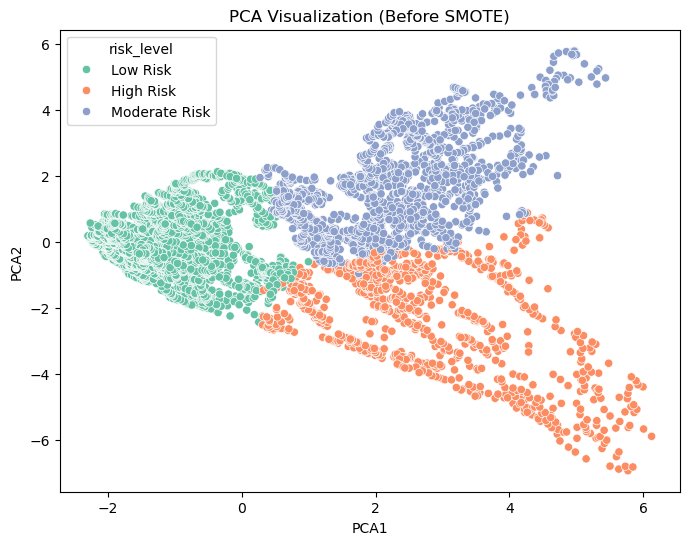

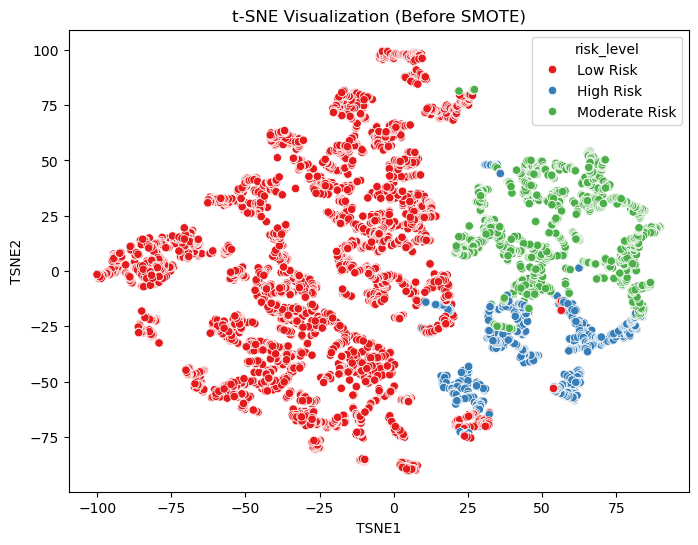

In [41]:
# 3. K-Nearest Neighbors (KNN) Classification

y_train = train['risk_level']
y_test = test['risk_level']

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

evaluate_model(y_test, y_pred, "KNN Baseline", label_names=['Low Risk', 'Moderate Risk', 'High Risk'])

# Visualizations before SMOTE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
train['PCA1'], train['PCA2'] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=train, x='PCA1', y='PCA2', hue='risk_level', palette='Set2')
plt.title('PCA Visualization (Before SMOTE)')
plt.show()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train)
train['TSNE1'], train['TSNE2'] = X_tsne[:, 0], X_tsne[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=train, x='TSNE1', y='TSNE2', hue='risk_level', palette='Set1')
plt.title('t-SNE Visualization (Before SMOTE)')
plt.show()


Before applying any class balancing techniques (such as SMOTE), I visualized the high-dimensional features space using PCA visualization and t-SNE. As each point represents a stock observation colored by risk-levels. Based on the results the clusters are mostly seperable, though moderate and high risk overlap, possible overlapping between those two risk type stocks is observed.  
I observed a significant class imbalance in the dataset to the majority class (Moderate Risk) and perform poorly on minority classes (High Risk), to solve this Issue I applied SMOTE to balance the class distribution to see how the model learns. 

#### 2. KNN with SMOTE 


📊 Evaluation Report for KNN with SMOTE
----------------------------------------
               precision    recall  f1-score   support

     Low Risk       0.36      0.98      0.53       820
Moderate Risk       0.99      0.62      0.76      3498
    High Risk       0.89      0.59      0.71       368

     accuracy                           0.68      4686
    macro avg       0.74      0.73      0.66      4686
 weighted avg       0.87      0.68      0.71      4686

Confusion Matrix:
[[ 807    0   13]
 [1323 2160   15]
 [ 122   29  217]]
Accuracy: 0.6795


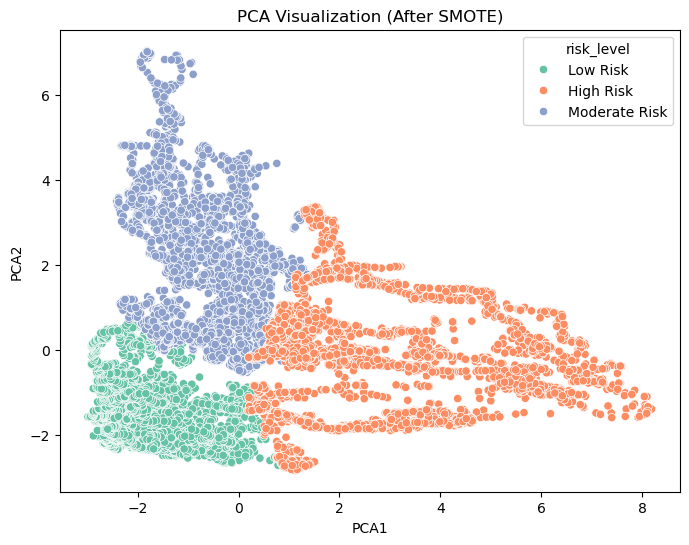

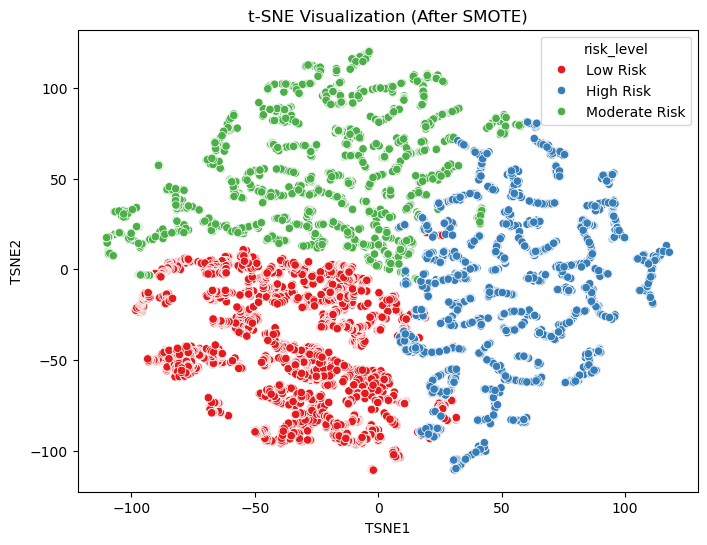

In [42]:
### Using SMOTE 

# 4. Handle Class Imbalance with SMOTE and Retrain KNN

risk_label_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
y_train_encoded = train['risk_level'].map(risk_label_map)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_encoded)

knn.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = knn.predict(X_test)
test['predicted_risk_level'] = pd.Series(y_pred_resampled).map({v: k for k, v in risk_label_map.items()})

evaluate_model(
    test['risk_level'].map(risk_label_map),
    y_pred_resampled,
    "KNN with SMOTE",
    label_names=['Low Risk', 'Moderate Risk', 'High Risk']
)

# Visualizations after SMOTE
viz_df = pd.DataFrame(X_train_resampled, columns=features)
viz_df['risk_level'] = y_train_resampled.map({0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'})

X_pca_resampled = pca.fit_transform(X_train_resampled)
viz_df['PCA1'], viz_df['PCA2'] = X_pca_resampled[:, 0], X_pca_resampled[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=viz_df, x='PCA1', y='PCA2', hue='risk_level', palette='Set2')
plt.title('PCA Visualization (After SMOTE)')
plt.show()

X_tsne_resampled = tsne.fit_transform(X_train_resampled)
viz_df['TSNE1'], viz_df['TSNE2'] = X_tsne_resampled[:, 0], X_tsne_resampled[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=viz_df, x='TSNE1', y='TSNE2', hue='risk_level', palette='Set1')
plt.title('t-SNE Visualization (After SMOTE)')
plt.show()


To address the class imbalance observed in the dataset, I applied SMOTE (Synthetic Minority Over-sampling Technique) on the training data. This method generates synthetic samples for the minority classes to balance the class distribution. I encoded the risk levels into numeric labels, applied SMOTE to resample the training features and labels, then retrained the KNN classifier on the balanced data. The results shows a strong improvement in recall for the Low Risk but some trade-offs for other classes. 

#### 3. XGBoost Classification with Sample Weights  
To further improve the model's performance and handle class imbalance issue, I trained an **XGboost classifier with sample weights**. These weights were  computed to balance the classes during training, giving more importance to minority classes.  
Dropped any rows with missing risk_level values from both training and test sets. Encoded the categorical risk levels into integers for model compatibility.Computed balanced sample weights using compute_sample_weight to mitigate class imbalance.

In [43]:
# 5. XGBoost Classification with Sample Weights

# Drop rows with NA in risk_level (if any)
train = train.dropna(subset=['risk_level'])
test = test.dropna(subset=['risk_level'])

# Map risk levels to integers for XGBoost
y_train_xgb = train['risk_level'].map(risk_label_map).astype(int)
y_test_xgb = test['risk_level'].map(risk_label_map).astype(int)

X_train_xgb = train[features]
X_test_xgb = test[features]

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluation
evaluate_model(
    y_test_xgb,
    y_pred_xgb,
    model_name="XGBoost with Class Weights",
    label_names=['Low Risk', 'Moderate Risk', 'High Risk']
)




📊 Evaluation Report for XGBoost with Class Weights
----------------------------------------
               precision    recall  f1-score   support

     Low Risk       0.59      0.94      0.72       820
Moderate Risk       0.99      0.86      0.92      3498
    High Risk       0.85      0.76      0.80       368

     accuracy                           0.87      4686
    macro avg       0.81      0.85      0.81      4686
 weighted avg       0.91      0.87      0.88      4686

Confusion Matrix:
[[ 771    8   41]
 [ 486 3002   10]
 [  60   27  281]]
Accuracy: 0.8651


As the XGboost model was made to predict risk levels on the test set. The XGBoost model achieved a huge improvement in overall **accuracy (87%)** compared to previous approaches. The recall for the Low Risk class increased substantially, indicating better recognition of minority classes while maintaining strong performance on the majority class.

## Next-Day Trend Predictions Models

### I. Machine Learning Models

In [44]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])  # train model on train set
    preds = model.predict(test[predictors])        # predict on test set
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis=1)  # combine true & predicted
    return combined

#### AAPL Model

##### 1. Baseline Model - RandomForestClassifier

RandomForestClassifier is particularly useful for next-day stock trend prediction due to its ability to handle noisy, high-dimensional financial data while mitigating overfitting. By aggregating predictions from multiple decision trees trained on random data subsets and features, the model captures complex nonlinear relationships between variables like price movements, technical indicators, and market sentiment.

In [45]:
model_v1 = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=42)

train_v1 = AAPL_data.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test_v1 = AAPL_data.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

predictors = ['open_value', 'high_value', 'low_value', 'close_value', 'volume']

# Use predict() function to train on train and predict on test, returning true & predicted labels
results_train = predict(train_v1, train_v1, predictors, model_v1)
results_test = predict(train_v1, test_v1, predictors, model_v1)    

##### 2. Baseline Model + Additional Features - RandomForestClassifier

In [46]:
# Make a copy of the original data
AAPL_data_addfeat = AAPL_data.copy()

# Define the horizons and initial predictors
horizons = [2, 5, 60, 250]
new_predictors = ['inflation_cpi', 'interest_rate_fed_funds', 'macd', 'atr']

# Loop through each horizon to create new features
for horizon in horizons:
    # Rolling average of 'close_value'
    rolling_avg = AAPL_data_addfeat['close_value'].rolling(horizon).mean()

    # Close ratio: current close value divided by rolling average
    ratio_column = f'Close_Ratio_{horizon}'
    AAPL_data_addfeat[ratio_column] = AAPL_data_addfeat['close_value'] / rolling_avg

    # Trend: sum of 'Target' values over the past 'horizon' days, shifted to avoid lookahead bias
    trend_column = f'Trend_{horizon}'
    AAPL_data_addfeat[trend_column] = AAPL_data_addfeat['Target'].shift(1).rolling(horizon).sum()

    # Add new feature names to the predictors list
    new_predictors += [ratio_column, trend_column]

AAPL_data_addfeat = AAPL_data_addfeat.dropna()

In [47]:
model_v2 = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)

train_addfeat = AAPL_data_addfeat.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test_addfeat = AAPL_data_addfeat.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

results_train_addfeat = predict(train_addfeat, train_addfeat, new_predictors, model_v2)
results_test_addfeat = predict(train_addfeat, test_addfeat, new_predictors, model_v2)  

##### 3. RandomForestClassifier with Wavelet Denoising

Wavelet denoising is used to reduce noise in financial time series while preserving important patterns like trends and sudden changes. Stock price data is often noisy due to market micro-movements, irregular trades, or external shocks. This noise can mislead machine learning models, especially when predicting short-term trends like next-day price movement. By applying wavelet denoising, I smooth out high-frequency noise without distorting the underlying structure, helping the model focus on meaningful signals that are more likely correlated with actual stock trends (up/down).

In [48]:
AAPL_data_wd = AAPL_data.copy()

def wavelet_denoise(series, wavelet='db4', level=3):
    coeffs = pywt.wavedec(series, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(series)))
    coeffs_thresholded = [coeffs[0]] + [pywt.threshold(c, threshold, 'soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs_thresholded, wavelet)[:len(series)]

In [49]:
# Feature Engineering
AAPL_data_wd['Denoised_Close'] = wavelet_denoise(AAPL_data_wd['close_value'])
AAPL_data_wd['Returns'] = AAPL_data_wd['Denoised_Close'].pct_change()
AAPL_data_wd['RSI'] = 100 - 100/(1 + AAPL_data_wd['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             AAPL_data_wd['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
AAPL_data_wd['Tomorrow'] = AAPL_data_wd['Denoised_Close'].shift(-1) 
AAPL_data_wd['Target'] = (AAPL_data_wd['Tomorrow'] > AAPL_data_wd['Denoised_Close']).astype(int)
AAPL_data_wd.dropna(inplace=True)

# Splitting the data
train_v3 = AAPL_data_wd.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test_v3 = AAPL_data_wd.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

X_train_aapl = train_v3[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_aapl = train_v3['Target']  
X_test_aapl = test_v3[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_aapl = test_v3['Target'] 

In [50]:
AAPL_data_wd.head()

,company_prefix,open_value,low_value,high_value,close_value,volume,rsi_14,macd,atr,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds,Tomorrow,Target,Denoised_Close,Returns,RSI
date_value,,,,,,,,,,,,,,,,,,
2015-03-09,AAPL,31.9900,31.2650,32.3925,31.7850,354096672.0,48.090843,0.039540,0.630086,5.375706,236.047913,15.060000,0.112431,31.165137,0,31.236052,-0.005899,20.517844
2015-03-10,AAPL,31.6025,30.9500,31.8050,31.1275,275338928.0,39.389168,0.005281,0.667407,5.373252,236.053970,16.690001,0.112800,31.143271,0,31.165137,-0.002270,17.194739
2015-03-11,AAPL,31.1875,30.5275,31.1925,30.5600,275578544.0,35.770197,-0.124092,0.702407,5.370988,236.059631,16.870001,0.113177,31.211755,1,31.143271,-0.000702,14.279161
2015-03-12,AAPL,30.5775,30.4075,31.2250,31.1125,193446232.0,39.025112,-0.231358,0.734907,5.368934,236.064972,15.420000,0.113560,31.266787,1,31.211755,0.002199,14.804925
2015-03-13,AAPL,31.1000,30.6450,31.3488,30.8975,207307132.0,26.868695,-0.280448,0.722593,5.367106,236.070068,16.000000,0.113949,31.303233,1,31.266787,0.001763,13.609138


In [51]:
model_v3 = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_v3.fit(X_train_aapl, y_train_aapl)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

#### CRWD Model

In [52]:
# Feature Engineering
CRWD_data['Denoised_Close'] = wavelet_denoise(CRWD_data['close_value'])
CRWD_data['Returns'] = CRWD_data['Denoised_Close'].pct_change()
CRWD_data['RSI'] = 100 - 100/(1 + CRWD_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             CRWD_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
CRWD_data['Tomorrow'] = CRWD_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
CRWD_data['Target'] = (CRWD_data['Tomorrow'] > CRWD_data['Denoised_Close']).astype(int)
CRWD_data.dropna(inplace=True)

#Splitting the data
train_crwd = CRWD_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_crwd = CRWD_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_crwd = train_crwd[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_crwd = train_crwd['Target']  
X_test_crwd = test_crwd[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_crwd = test_crwd['Target']  

model_crwd = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)
model_crwd.fit(X_train_crwd, y_train_crwd)

RandomForestClassifier(class_weight='balanced', min_samples_split=50,
                       n_estimators=200, random_state=42)

#### KLAC Model

In [53]:
# Feature Engineering
KLAC_data['Denoised_Close'] = wavelet_denoise(KLAC_data['close_value'])
KLAC_data['Returns'] = KLAC_data['Denoised_Close'].pct_change()
KLAC_data['RSI'] = 100 - 100/(1 + KLAC_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             KLAC_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
KLAC_data['Tomorrow'] = KLAC_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
KLAC_data['Target'] = (KLAC_data['Tomorrow'] > KLAC_data['Denoised_Close']).astype(int)
KLAC_data.dropna(inplace=True)

# Splitting the data
train_klac = KLAC_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_klac = KLAC_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_klac = train_klac[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_klac = train_klac['Target']  
X_test_klac = test_klac[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_klac = test_klac['Target']  

model_klac = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)
model_klac.fit(X_train_klac, y_train_klac)

RandomForestClassifier(class_weight='balanced', min_samples_split=50,
                       n_estimators=200, random_state=42)

#### MSFT Model

In [54]:
# Feature Engineering
MSFT_data['Denoised_Close'] = wavelet_denoise(MSFT_data['close_value'])
MSFT_data['Returns'] = MSFT_data['Denoised_Close'].pct_change()
MSFT_data['RSI'] = 100 - 100/(1 + MSFT_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             MSFT_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
MSFT_data['Tomorrow'] = MSFT_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
MSFT_data['Target'] = (MSFT_data['Tomorrow'] > MSFT_data['Denoised_Close']).astype(int)
MSFT_data.dropna(inplace=True)

#Splitting the data
train_msft = MSFT_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_msft = MSFT_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_msft = train_msft[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_msft = train_msft['Target'] 
X_test_msft = test_msft[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_msft = test_msft['Target']  

model_msft = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_msft.fit(X_train_msft, y_train_msft)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

#### PLTR Model

In [55]:
# Feature Engineering
PLTR_data['Denoised_Close'] = wavelet_denoise(PLTR_data['close_value'])
PLTR_data['Returns'] = PLTR_data['Denoised_Close'].pct_change()
PLTR_data['RSI'] = 100 - 100/(1 + PLTR_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             PLTR_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
PLTR_data['Tomorrow'] = PLTR_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
PLTR_data['Target'] = (PLTR_data['Tomorrow'] > PLTR_data['Denoised_Close']).astype(int)
PLTR_data.dropna(inplace=True)

# Splitting the data
train_pltr = PLTR_data.loc[:datetime.strptime('2024-02-13', '%Y-%m-%d').date()]
test_pltr = PLTR_data.loc[datetime.strptime('2024-02-14', '%Y-%m-%d').date():]

X_train_pltr = train_pltr[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_pltr = train_pltr['Target'] 
X_test_pltr = test_pltr[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_pltr = test_pltr['Target']

model_pltr = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_pltr.fit(X_train_pltr, y_train_pltr)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

#### QCOM Model

In [56]:
# Feature Engineering
QCOM_data['Denoised_Close'] = wavelet_denoise(QCOM_data['close_value'])
QCOM_data['Returns'] = QCOM_data['Denoised_Close'].pct_change()
QCOM_data['RSI'] = 100 - 100/(1 + QCOM_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             QCOM_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
QCOM_data['Tomorrow'] = QCOM_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
QCOM_data['Target'] = (QCOM_data['Tomorrow'] > QCOM_data['Denoised_Close']).astype(int)
QCOM_data.dropna(inplace=True)

# Splitting the data
train_qcom = QCOM_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_qcom = QCOM_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_qcom = train_qcom[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_qcom = train_qcom['Target']  
X_test_qcom = test_qcom[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_qcom = test_qcom['Target'] 

model_qcom = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_qcom.fit(X_train_qcom, y_train_qcom)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

### Merging all of the data

In [57]:
# Reset index to bring 'date_value' into a column
AAPL_data_wd = AAPL_data_wd.reset_index()
CRWD_data = CRWD_data.reset_index()
MSFT_data = MSFT_data.reset_index()
PLTR_data = PLTR_data.reset_index()
KLAC_data = KLAC_data.reset_index()
QCOM_data = QCOM_data.reset_index()

# Combine all DataFrames
all_data = pd.concat([AAPL_data_wd, CRWD_data, MSFT_data, PLTR_data, KLAC_data, QCOM_data], ignore_index=True)

# Sort by date_value ascending
all_data = all_data.sort_values('date_value').reset_index(drop=True)

In [58]:
data = data.drop(columns=['Tomorrow', 'Target'], errors='ignore')

In [59]:
# Ensure date_value is of same type (date only, not datetime)
data['date_value'] = pd.to_datetime(data['date_value']).dt.date
all_data['date_value'] = pd.to_datetime(all_data['date_value']).dt.date

# Normalize company_prefix to uppercase
data['company_prefix'] = data['company_prefix'].str.upper()
all_data['company_prefix'] = all_data['company_prefix'].str.upper()

In [60]:
new_features = all_data[['date_value', 'company_prefix', 'Denoised_Close', 'Returns', 'RSI', 'Tomorrow', 'Target']]

In [61]:
data = data.merge(new_features, on=['date_value', 'company_prefix'], how='inner')

In [62]:
data.isna().sum()

date_value                           0
company_prefix                       0
open_value                           0
close_value                          0
low_value                            0
high_value                           0
volume                               0
return_1d                            0
return_3d                            0
sma_10                               0
sma_50                               0
sma_diff                             0
rsi_14                               0
atr                                  0
macd                                 0
unemployment_rate                    0
inflation_cpi                        0
stock_market_volatility_vix_index    0
interest_rate_fed_funds              0
daily_return                         0
volatility_30                        0
max_drawdown                         0
avg_volume                           0
momentum                             0
cluster                              0
risk_level               

### II. Rule-based Models

In [63]:
data_rulebased = data.copy()

In [64]:
# Convert 'date_value' to datetime if it's not already
data_rulebased['date_value'] = pd.to_datetime(data_rulebased['date_value'])

# Set 'date_value' as the index
data_rulebased.set_index('date_value', inplace=True)

#### 1. Buy & Hold: Buy at the start, hold until the end

In [65]:
data_rulebased.head()

,company_prefix,open_value,close_value,low_value,high_value,volume,return_1d,return_3d,sma_10,sma_50,...,max_drawdown,avg_volume,momentum,cluster,risk_level,Denoised_Close,Returns,RSI,Tomorrow,Target
date_value,,,,,,,,,,,,,,,,,,,,,
2015-03-09,MSFT,42.19,42.850,42.190,43.1250,32107782.0,1.156752,-0.476135,43.45200,43.542333,...,0.144195,2.854164e+07,-0.023473,1,Medium Risk,41.937581,-0.006863,18.196999,41.823237,0
2015-03-09,KLAC,61.01,61.370,61.010,61.6600,1178154.0,0.507697,-2.818686,64.00300,64.157000,...,0.203802,1.365341e+06,-0.065906,1,Medium Risk,60.606966,-0.010841,21.462329,60.393428,0
2015-03-09,AAPL,31.99,31.785,31.265,32.3925,354096672.0,0.426540,-1.089155,32.17438,32.241093,...,0.175620,1.142465e+08,-0.015106,2,Low Risk,31.236052,-0.005899,20.517844,31.165137,0
2015-03-09,QCOM,71.64,72.705,71.640,72.8700,12754658.0,1.678204,2.625450,71.76150,71.493000,...,0.205274,1.052570e+07,0.000688,1,Medium Risk,71.030777,-0.002527,53.562936,70.871171,0
2015-03-10,QCOM,73.87,71.885,71.860,74.0900,28811328.0,-1.127845,1.346398,71.81300,71.517500,...,0.205274,1.052570e+07,0.006722,1,Medium Risk,70.871171,-0.002247,45.692066,70.708476,0


In [66]:
def buy_and_hold_from_cleaned_data(data_rulebased, company_prefix, investment):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")

    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Buy at first available date, sell at last
    buy_price = data_rulebased['close_value'].iloc[0]
    sell_price = data_rulebased['close_value'].iloc[-1]
    buy_date = data_rulebased.index[0].date()
    sell_date = data_rulebased.index[-1].date()

    num_shares = investment // buy_price
    remaining_cash = investment - (num_shares * buy_price)
    final_value = (num_shares * sell_price) + remaining_cash
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nBuy & Hold Results for {company_prefix}:")
    print(f"Buy Date: {buy_date} | Buy Price: ${buy_price:.2f}")
    print(f"Sell Date: {sell_date} | Sell Price: ${sell_price:.2f}")
    print(f"Shares Bought: {num_shares}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    # Portfolio value over time
    data_rulebased['Portfolio Value'] = (data_rulebased['close_value'] * num_shares) + remaining_cash

    return data_rulebased

In [67]:
def plot_portfolio_value(data_rulebased, company_prefix):
    plt.figure(figsize=(10, 6))
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value')
    plt.title(f"Portfolio Value Over Time (Buy & Hold) - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Buy & Hold Results for AAPL:
Buy Date: 2015-03-09 | Buy Price: $31.79
Sell Date: 2025-02-11 | Sell Price: $232.62
Shares Bought: 31.0
Final Portfolio Value: $7225.89
Total Profit: $6225.89
ROI: 622.59%



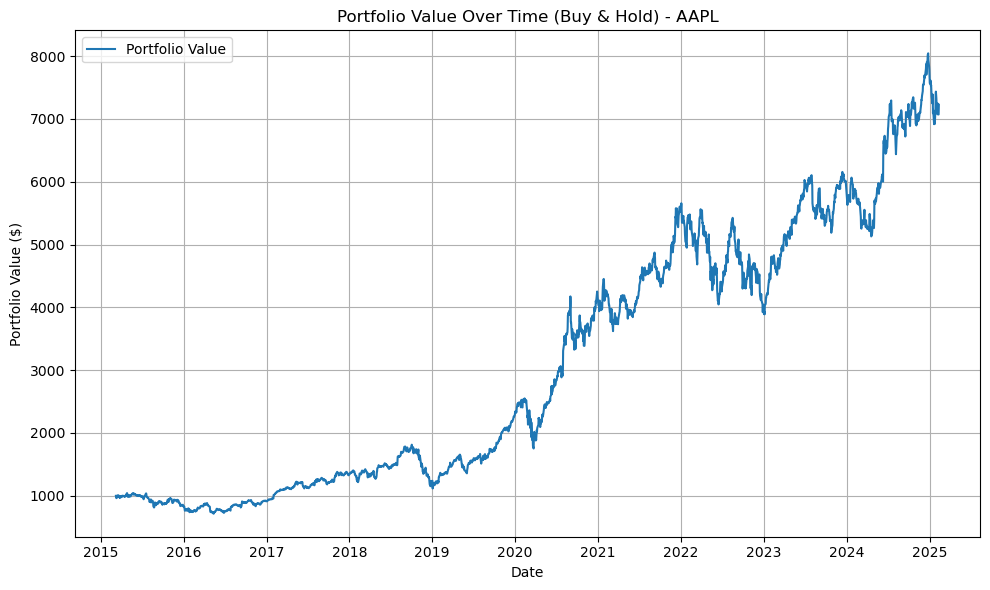

In [68]:
# Example usage 
company_prefix = 'AAPL'
investment = 1000

results_df = buy_and_hold_from_cleaned_data(data_rulebased, company_prefix, investment)
if results_df is not None:
    plot_portfolio_value(results_df, company_prefix)

#### 2. Moving Average Crossover

Simulating a trading strategy where you "buy" a stock when the short-term moving average crosses above the long-term moving average (a bullish signal) and "sell" when it crosses below (a bearish signal)

In [69]:
def moving_average_crossover(data_rulebased, company_prefix, investment):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")
        return None

    # Ensure the index is datetime and sorted
    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Use existing columns
    data_rulebased['short_ma'] = data_rulebased['sma_10']
    data_rulebased['long_ma'] = data_rulebased['sma_50']
    data_rulebased['sma_diff'] = data_rulebased['sma_diff']

    # Initialize signal column with zeros
    data_rulebased['signal'] = 0

    # Calculate buy signals (1) where sma_diff crosses from <=0 to >0
    buy_signals = ((data_rulebased['sma_diff'].values[1:] > 0) & (data_rulebased['sma_diff'].values[:-1] <= 0)).astype(int)
    # Calculate sell signals (-1) where sma_diff crosses from >=0 to <0
    sell_signals = ((data_rulebased['sma_diff'].values[1:] < 0) & (data_rulebased['sma_diff'].values[:-1] >= 0)).astype(int)
    # Assign buy and sell signals using .loc to avoid chained assignment
    data_rulebased.loc[data_rulebased.index[1:], 'signal'] = buy_signals - sell_signals

    # Simulate trading
    cash = investment
    shares = 0
    portfolio_values = []
    positions = []

    for idx, row in data_rulebased.iterrows():
        # Buy signal
        if row['signal'] == 1 and cash > 0:
            shares = cash // row['close_value']
            cash -= shares * row['close_value']
        # Sell signal
        elif row['signal'] == -1 and shares > 0:
            cash += shares * row['close_value']
            shares = 0
        # Calculate portfolio value at each step
        portfolio_value = cash + shares * row['close_value']
        portfolio_values.append(portfolio_value)
        positions.append(shares)

    data_rulebased['Portfolio Value'] = portfolio_values
    data_rulebased['Shares Held'] = positions

    # Final stats
    final_value = data_rulebased['Portfolio Value'].iloc[-1]
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nMoving Average Crossover Results for {company_prefix}:")
    print(f"Initial Investment: ${investment:.2f}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    return data_rulebased

In [70]:
def plot_ma_crossover(data_rulebased, company_prefix):
    plt.figure(figsize=(12, 7))
    plt.plot(data_rulebased.index, data_rulebased['close_value'], label='Close Price', color='black')
    plt.plot(data_rulebased.index, data_rulebased['short_ma'], label='SMA 10', color='blue', alpha=0.7)
    plt.plot(data_rulebased.index, data_rulebased['long_ma'], label='SMA 50', color='red', alpha=0.7)
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value', color='green', linestyle='--', alpha=0.6)
    plt.title(f"Moving Average Crossover Strategy - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Price / Portfolio Value ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Moving Average Crossover Results for PLTR:
Initial Investment: $1000.00
Final Portfolio Value: $6237.36
Total Profit: $5237.36
ROI: 523.74%



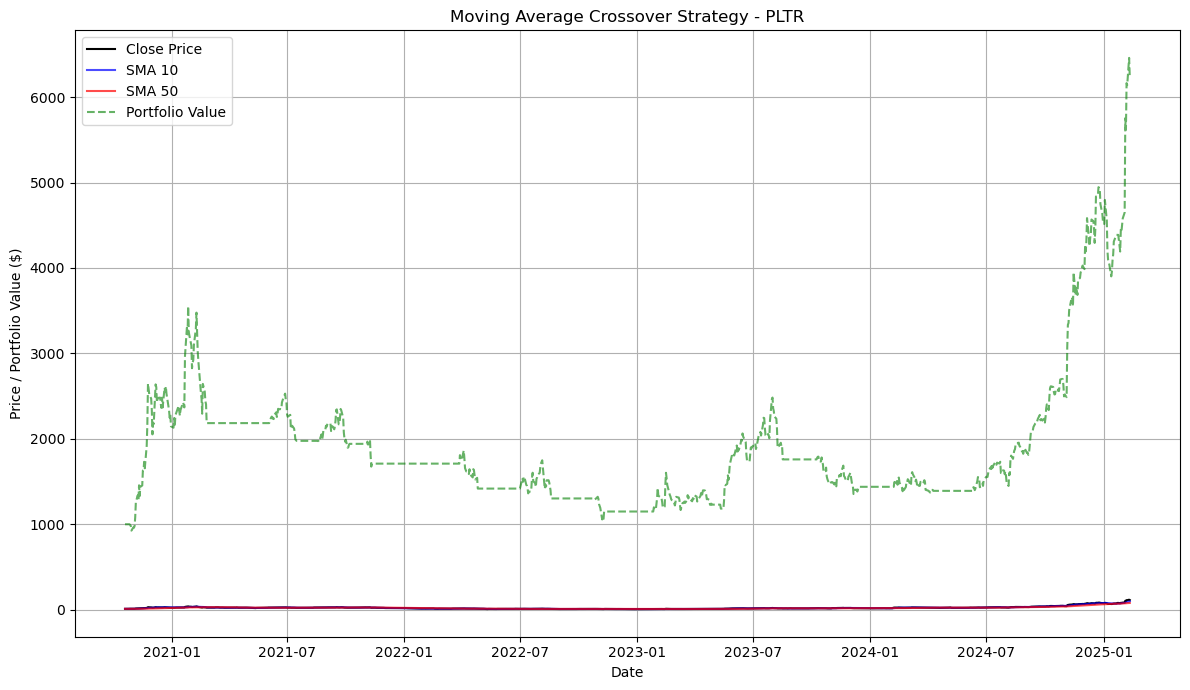

In [71]:
# Example usage
company_prefix = 'PLTR'
investment = 1000
results_ma = moving_average_crossover(data_rulebased, company_prefix, investment)

if results_ma is not None:
    plot_ma_crossover(results_ma, company_prefix)

#### 3. RSI Based

In [72]:
def rsi_based_strategy(data_rulebased, company_prefix, investment, rsi_column='rsi_14', rsi_buy_threshold=30, rsi_sell_threshold=70):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")
        return None

    # Ensure the index is datetime and sorted
    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Initialize signal column: 1 for buy, -1 for sell, 0 for hold
    data_rulebased['signal'] = 0

    # Buy: RSI crosses above buy threshold (oversold)
    buy_signals = ((data_rulebased[rsi_column].values[1:] > rsi_buy_threshold) & (data_rulebased[rsi_column].values[:-1] <= rsi_buy_threshold)).astype(int)
    # Sell: RSI crosses below sell threshold (overbought)
    sell_signals = ((data_rulebased[rsi_column].values[1:] < rsi_sell_threshold) & (data_rulebased[rsi_column].values[:-1] >= rsi_sell_threshold)).astype(int)

    # Assign signals using .loc to avoid chained assignment
    data_rulebased.loc[data_rulebased.index[1:], 'signal'] = buy_signals - sell_signals

    # Simulate trading
    cash = investment
    shares = 0
    portfolio_values = []
    positions = []

    for idx, row in data_rulebased.iterrows():
        # Buy signal
        if row['signal'] == 1 and cash > 0:
            shares = cash // row['close_value']
            cash -= shares * row['close_value']
        # Sell signal
        elif row['signal'] == -1 and shares > 0:
            cash += shares * row['close_value']
            shares = 0
        # Calculate portfolio value at each step
        portfolio_value = cash + shares * row['close_value']
        portfolio_values.append(portfolio_value)
        positions.append(shares)

    data_rulebased['Portfolio Value'] = portfolio_values
    data_rulebased['Shares Held'] = positions

    # Final stats
    final_value = data_rulebased['Portfolio Value'].iloc[-1]
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nRSI-Based Strategy Results for {company_prefix}:")
    print(f"Initial Investment: ${investment:.2f}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    return data_rulebased

In [73]:
def plot_rsi_strategy(data_rulebased, company_prefix):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 7))
    plt.plot(data_rulebased.index, data_rulebased['close_value'], label='Close Price', color='black')
    plt.plot(data_rulebased.index, data_rulebased['rsi_14'], label='RSI 14', color='purple', alpha=0.7)
    plt.axhline(30, color='green', linestyle='--', label='RSI Buy Threshold (30)')
    plt.axhline(70, color='red', linestyle='--', label='RSI Sell Threshold (70)')
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value', color='green', linestyle='--', alpha=0.6)
    plt.title(f"RSI-Based Strategy - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Price / RSI / Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


RSI-Based Strategy Results for CRWD:
Initial Investment: $1000.00
Final Portfolio Value: $8.13
Total Profit: $-991.87
ROI: -99.19%



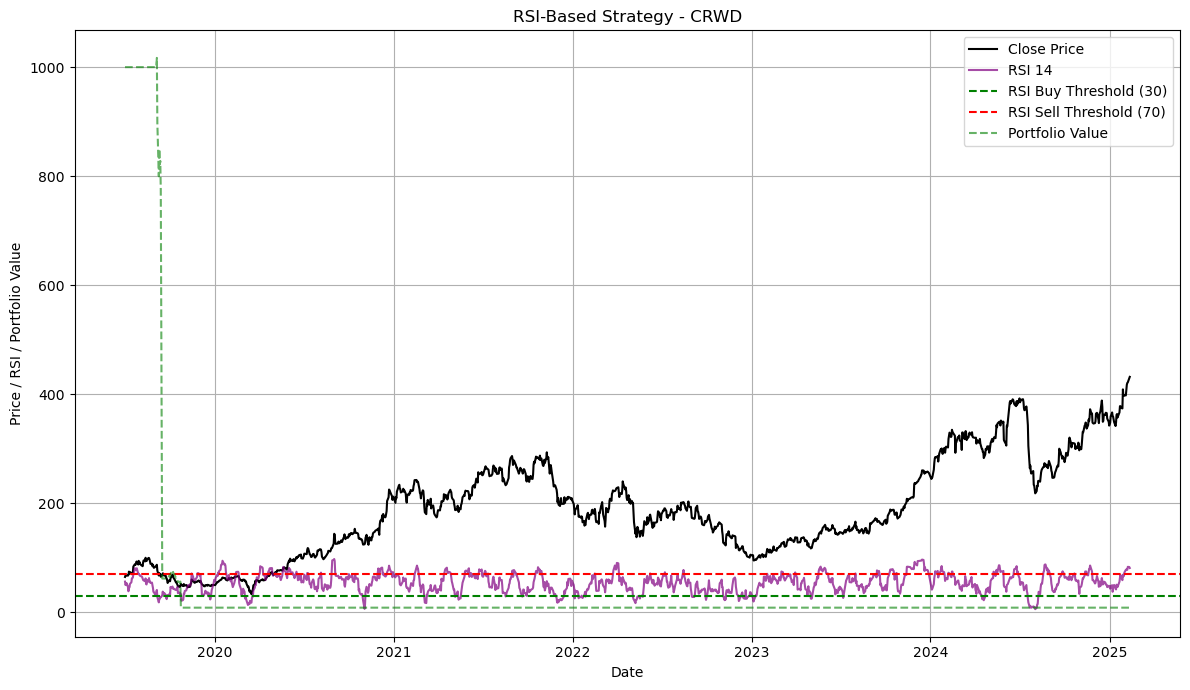

In [74]:
# Example usage (assuming cleaned_data is already loaded)
company_prefix = 'CRWD'
investment = 1000
results_rsi = rsi_based_strategy(data_rulebased, company_prefix, investment)
if results_rsi is not None:
    plot_rsi_strategy(results_rsi, company_prefix)

# 📈 Step 5: Model Evaluation

Evaluate your models using suitable metrics for your problem, such as:
- Accuracy, Precision, Recall, F1-score (for classification)
- RMSE, MAE, R-squared (for regression)
- Silhouette Score, Davies-Bouldin Index (for clustering)

Ensure proper validation techniques such as cross-validation or backtesting.


📌  In addition to evaluating the performance of your developed model, compute a baseline performance metric (e.g., using a naive forecast, mean predictor, or a simple model). This baseline will serve as a reference point to help you assess how well your model performs compared to a simple alternative.


# Clustering Model

### 1. K-Means Clustering for Risk Tier Assignment (Silhouette score)

In [75]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_train, train['cluster'])
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.379


### 2. K-Means Clustering for Risk Tier Assignment (Davies-Bouldin Index )

In [76]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(X_train, train['cluster'])
print(f"Davies-Bouldin Index (K-Means, k=3): {db_index:.3f}")


Davies-Bouldin Index (K-Means, k=3): 1.397


### 3. Company-Specific Risk Classification

In [77]:
# Single Company Risk Prediction Example (e.g., for Dashboard)

selected_ticker = 'PLTR'  # Example ticker, replace with user input
latest_data = df_cluster_model[df_cluster_model['company_prefix'] == selected_ticker].sort_values('date_value').iloc[-1]

user_input = latest_data[features].values.reshape(1, -1)

pred_class = xgb_model.predict(user_input)[0]
pred_label = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}[pred_class]

print(f"Company's Stock: {selected_ticker}")
print(f"Predicted Risk Category: {pred_label}")

probs = xgb_model.predict_proba(user_input)[0]
print("Confidence Scores:")
for i, label in enumerate(risk_levels):
    print(f"{label}: {probs[i]:.2f}")

Company's Stock: PLTR
Predicted Risk Category: High Risk
Confidence Scores:
Low Risk: 0.00
Moderate Risk: 0.00
High Risk: 1.00


### 4. KNN Classification Results (Before SMOTE) **Baseline Model**

In [78]:
from sklearn.metrics import classification_report, accuracy_score

y_train = train['risk_level']
y_test = test['risk_level']

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Print evaluation metrics
print("Classification Report (KNN):")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Classification Report (KNN):
               precision    recall  f1-score   support

    High Risk       0.94      0.51      0.66       368
     Low Risk       0.35      0.99      0.52       820
Moderate Risk       0.99      0.61      0.76      3498

     accuracy                           0.67      4686
    macro avg       0.76      0.71      0.65      4686
 weighted avg       0.87      0.67      0.71      4686

Accuracy: 0.6720


### 5. KNN Classification Results (After SMOTE)

In [79]:
from sklearn.metrics import classification_report, accuracy_score

risk_label_map = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
y_train_encoded = train['risk_level'].map(risk_label_map)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_encoded)

knn.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = knn.predict(X_test)

# Evaluation metrics
print("Classification Report (KNN with SMOTE):")
print(classification_report(test['risk_level'].map(risk_label_map), y_pred_resampled))
print(f"Accuracy: {accuracy_score(test['risk_level'].map(risk_label_map), y_pred_resampled):.4f}")


Classification Report (KNN with SMOTE):
              precision    recall  f1-score   support

           0       0.36      0.98      0.53       820
           1       0.99      0.62      0.76      3498
           2       0.89      0.59      0.71       368

    accuracy                           0.68      4686
   macro avg       0.74      0.73      0.66      4686
weighted avg       0.87      0.68      0.71      4686

Accuracy: 0.6795


### 6. XGBoost Classification Results 

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_xgb = xgb_model.predict(X_test_xgb)

print("Classification Report (XGBoost):")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=risk_levels))

print("Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))


Classification Report (XGBoost):
               precision    recall  f1-score   support

     Low Risk       0.59      0.94      0.72       820
Moderate Risk       0.99      0.86      0.92      3498
    High Risk       0.85      0.76      0.80       368

     accuracy                           0.87      4686
    macro avg       0.81      0.85      0.81      4686
 weighted avg       0.91      0.87      0.88      4686

Confusion Matrix:
[[ 771    8   41]
 [ 486 3002   10]
 [  60   27  281]]
Accuracy: 0.8651301749893299


# Next-Day Trend Predictions Evaluation

In [81]:
# Evaluation function
def evaluate(true, preds, dataset_name):
    print(f"Evaluation on {dataset_name}:")
    print(f"  Accuracy:  {accuracy_score(true, preds):.4f}")
    print(f"  Precision: {precision_score(true, preds):.4f}")
    print(f"  Recall:    {recall_score(true, preds):.4f}")
    print(f"  F1 Score:  {f1_score(true, preds):.4f}")
    print()

## AAPL Models

### 1. AAPL - baseline

In [82]:
# Evaluate
evaluate(results_train['Target'], results_train['Predictions'], "Train Set")
evaluate(results_test['Target'], results_test['Predictions'], "Test Set")

Evaluation on Train Set:
  Accuracy:  0.7576
  Precision: 0.7323
  Recall:    0.8422
  F1 Score:  0.7834

Evaluation on Test Set:
  Accuracy:  0.4717
  Precision: 0.7059
  Recall:    0.0816
  F1 Score:  0.1463



### 2. AAPL - baseline + additional features

In [83]:
evaluate(train_addfeat['Target'], results_train_addfeat['Predictions'], 'Train Set')
evaluate(test_addfeat['Target'], results_test_addfeat['Predictions'], 'Test Set')

Evaluation on Train Set:
  Accuracy:  0.8552
  Precision: 0.8633
  Recall:    0.8643
  F1 Score:  0.8638

Evaluation on Test Set:
  Accuracy:  0.4480
  Precision: 1.0000
  Recall:    0.0068
  F1 Score:  0.0135



### 3. RandomForestClassifier with Wavelet Denoise

In [84]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label=""):
    # Predict on train and test sets
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate metrics
    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    # Print results
    print(f"{label}Train Precision Score: {train_precision:.2%}")
    print(f"{label}Test Precision Score: {test_precision:.2%}")
    print(f"{label}Train F1 Score: {train_f1:.2%}")
    print(f"{label}Test F1 Score: {test_f1:.2%}")
    print(f"{label}Train Accuracy Score: {train_accuracy:.2%}")
    print(f"{label}Test Accuracy Score: {test_accuracy:.2%}")
    print(f"{label}Train Recall Score: {train_recall:.2%}")
    print(f"{label}Test Recall Score: {test_recall:.2%}")

In [85]:
evaluate_model(model_v3, X_train_aapl, y_train_aapl, X_test_aapl, y_test_aapl, label='AAPL ')

AAPL Train Precision Score: 86.36%
AAPL Test Precision Score: 79.53%
AAPL Train F1 Score: 84.50%
AAPL Test F1 Score: 74.88%
AAPL Train Accuracy Score: 82.44%
AAPL Test Accuracy Score: 69.94%
AAPL Train Recall Score: 82.72%
AAPL Test Recall Score: 70.75%


In [86]:
def evaluate_model_with_threshold(model, X_train, y_train, X_test, y_test, threshold=0.5, label=""):
    # Predict probabilities for positive class
    proba_train = model.predict_proba(X_train)[:, 1]
    proba_test = model.predict_proba(X_test)[:, 1]

    # Apply custom threshold to get binary predictions
    train_pred = (proba_train >= threshold).astype(int)
    test_pred = (proba_test >= threshold).astype(int)

    # Calculate metrics
    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    # Print results
    print(f"{label}Train Precision Score: {train_precision:.2%}")
    print(f"{label}Test Precision Score: {test_precision:.2%}")
    print(f"{label}Train F1 Score: {train_f1:.2%}")
    print(f"{label}Test F1 Score: {test_f1:.2%}")
    print(f"{label}Train Accuracy Score: {train_accuracy:.2%}")
    print(f"{label}Test Accuracy Score: {test_accuracy:.2%}")
    print(f"{label}Train Recall Score: {train_recall:.2%}")
    print(f"{label}Test Recall Score: {test_recall:.2%}")

In [87]:
evaluate_model_with_threshold(model_v3, X_train_aapl, y_train_aapl, X_test_aapl, y_test_aapl, threshold=0.4, label= 'AAPL ')

AAPL Train Precision Score: 80.16%
AAPL Test Precision Score: 71.84%
AAPL Train F1 Score: 84.95%
AAPL Test F1 Score: 79.25%
AAPL Train Accuracy Score: 81.47%
AAPL Test Accuracy Score: 70.70%
AAPL Train Recall Score: 90.35%
AAPL Test Recall Score: 88.36%


## CRWD Model

In [88]:
# Predict on train and test sets using the correct model
evaluate_model(model_crwd, X_train_crwd, y_train_crwd, X_test_crwd, y_test_crwd, label='CRWD ')

CRWD Train Precision Score: 85.95%
CRWD Test Precision Score: 81.62%
CRWD Train F1 Score: 85.68%
CRWD Test F1 Score: 67.02%
CRWD Train Accuracy Score: 84.96%
CRWD Test Accuracy Score: 62.48%
CRWD Train Recall Score: 85.42%
CRWD Test Recall Score: 56.85%


In [89]:
evaluate_model_with_threshold(model_crwd, X_train_crwd, y_train_crwd, X_test_crwd, y_test_crwd, threshold=0.4, label= 'CRWD ')

CRWD Train Precision Score: 75.98%
CRWD Test Precision Score: 72.98%
CRWD Train F1 Score: 83.60%
CRWD Test F1 Score: 75.40%
CRWD Train Accuracy Score: 80.79%
CRWD Test Accuracy Score: 65.87%
CRWD Train Recall Score: 92.92%
CRWD Test Recall Score: 77.98%


## KLAC Model

In [90]:
evaluate_model(model_klac, X_train_klac, y_train_klac, X_test_klac, y_test_klac, label='KLAC ')

KLAC Train Precision Score: 90.64%
KLAC Test Precision Score: 74.66%
KLAC Train F1 Score: 88.05%
KLAC Test F1 Score: 62.74%
KLAC Train Accuracy Score: 86.44%
KLAC Test Accuracy Score: 60.88%
KLAC Train Recall Score: 85.59%
KLAC Test Recall Score: 54.10%


In [91]:
evaluate_model_with_threshold(model_klac, X_train_klac, y_train_klac, X_test_klac, y_test_klac, threshold=0.4, label= 'KLAC ')

KLAC Train Precision Score: 83.16%
KLAC Test Precision Score: 70.97%
KLAC Train F1 Score: 88.81%
KLAC Test F1 Score: 67.81%
KLAC Train Accuracy Score: 85.99%
KLAC Test Accuracy Score: 62.48%
KLAC Train Recall Score: 95.28%
KLAC Test Recall Score: 64.92%


## MSFT Model

In [92]:
evaluate_model(model_msft, X_train_msft, y_train_msft, X_test_msft, y_test_msft, label='MSFT ')

MSFT Train Precision Score: 88.75%
MSFT Test Precision Score: 79.59%
MSFT Train F1 Score: 83.50%
MSFT Test F1 Score: 70.91%
MSFT Train Accuracy Score: 80.18%
MSFT Test Accuracy Score: 68.06%
MSFT Train Recall Score: 78.84%
MSFT Test Recall Score: 63.93%


In [93]:
evaluate_model_with_threshold(model_msft, X_train_msft, y_train_msft, X_test_msft, y_test_msft, threshold=0.4, label="MSFT ")

MSFT Train Precision Score: 80.80%
MSFT Test Precision Score: 71.95%
MSFT Train F1 Score: 86.91%
MSFT Test F1 Score: 77.20%
MSFT Train Accuracy Score: 81.98%
MSFT Test Accuracy Score: 70.06%
MSFT Train Recall Score: 94.02%
MSFT Test Recall Score: 83.28%


## PLTR Model

In [94]:
evaluate_model(model_pltr, X_train_pltr, y_train_pltr, X_test_pltr, y_test_pltr, label='PLTR ')

PLTR Train Precision Score: 81.26%
PLTR Test Precision Score: 88.64%
PLTR Train F1 Score: 81.82%
PLTR Test F1 Score: 62.90%
PLTR Train Accuracy Score: 80.82%
PLTR Test Accuracy Score: 63.05%
PLTR Train Recall Score: 82.38%
PLTR Test Recall Score: 48.75%


In [95]:
evaluate_model_with_threshold(model_pltr, X_train_pltr, y_train_pltr, X_test_pltr, y_test_pltr,threshold=0.4, label='PLTR ')

PLTR Train Precision Score: 71.15%
PLTR Test Precision Score: 84.96%
PLTR Train F1 Score: 79.80%
PLTR Test F1 Score: 77.13%
PLTR Train Accuracy Score: 75.90%
PLTR Test Accuracy Score: 73.09%
PLTR Train Recall Score: 90.85%
PLTR Test Recall Score: 70.62%


## QCOM Model

In [96]:
evaluate_model(model_qcom, X_train_qcom, y_train_qcom, X_test_qcom, y_test_qcom, label='QCOM ')

QCOM Train Precision Score: 80.78%
QCOM Test Precision Score: 66.99%
QCOM Train F1 Score: 79.58%
QCOM Test F1 Score: 60.09%
QCOM Train Accuracy Score: 79.38%
QCOM Test Accuracy Score: 62.87%
QCOM Train Recall Score: 78.42%
QCOM Test Recall Score: 54.47%


In [97]:
evaluate_model_with_threshold(model_qcom, X_train_qcom, y_train_qcom, X_test_qcom, y_test_qcom, threshold=0.4, label='QCOM ')

QCOM Train Precision Score: 69.48%
QCOM Test Precision Score: 62.43%
QCOM Train F1 Score: 79.02%
QCOM Test F1 Score: 70.92%
QCOM Train Accuracy Score: 75.08%
QCOM Test Accuracy Score: 65.47%
QCOM Train Recall Score: 91.60%
QCOM Test Recall Score: 82.10%


# 🔧  Step 6: Hyperparameter Tuning

In this step, you will fine-tune the hyperparameters of your model to optimize its performance. Hyperparameters play a crucial role in determining the effectiveness of the model, and finding the right combination is essential for achieving the best results.


👉 Do not forget to provide evidence showing how fine-tuning hyperparameters can improve model performance. You might consider presenting the model's performance with different sets of hyperparameters.

🔧 You are required to fine-tune **all relevant and impactful hyperparameters** of your model—not just a single one. Consider the full set of hyperparameters that could influence model performance. You may perform this tuning using **manual search (by hand)**, or automated methods such as **grid search**, **random search**, or **cross-validation**. Be sure to justify your choices and explain how the tuning impacted your model’s performance.

After completing the hyperparameter tuning process, you must **explicitly state which model configuration you have selected for deployment**. This should include the tuned hyperparameters and a brief justification for why this model was chosen based on its performance and relevance to the problem.

# Next-Day Trend Predictions Hyperparameter Tuning

This code defines the range of hyperparameters for RandomizedSearchCV to tune the Random Forest model. It specifies:

* `n_estimators`: number of trees, randomly chosen between 100 and 400
* `max_depth`: max depth of each tree, either unlimited (`None`) or from 5 to 20 in steps of 5
* `min_samples_split`: minimum samples to split a node, between 2 and 100
* `min_samples_leaf`: minimum samples required at a leaf node, between 1 and 50
* `max_features`: number of features considered at each split, either ‘sqrt’, ‘log2’, or all features (`None`)

By sampling from these ranges, RandomizedSearchCV searches many combinations to find the best hyperparameter set that improves model performance efficiently.


In [98]:
# --- Hyperparameter distributions for RandomizedSearchCV ---
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [None] + list(range(5, 21, 5)),
    'min_samples_split': randint(2, 100),
    'min_samples_leaf': randint(1, 50),
    'max_features': ['sqrt', 'log2', None]
}


## AAPL Model - Hyperparameter Tuning

In [99]:
# --- Initialize the Random Forest classifier ---
aapl_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=aapl_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_aapl, y_train_aapl)

# --- Retrieve and evaluate the best model ---
best_aapl_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_aapl = best_aapl_ht.predict(X_test_aapl)
print(classification_report(y_test_aapl, y_pred_aapl))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 22, 'min_samples_split': 54, 'n_estimators': 357}
              precision    recall  f1-score   support

           0       0.57      0.67      0.61       194
           1       0.79      0.70      0.74       335

    accuracy                           0.69       529
   macro avg       0.68      0.69      0.68       529
weighted avg       0.71      0.69      0.70       529



The tuned model for AAPL significantly deepened the trees to a max depth of 20 and increased the number of estimators to 357, suggesting the complexity of AAPL’s data benefits from deeper, more numerous trees. Larger min_samples_leaf (22) and moderate min_samples_split (54) help control overfitting while allowing the model to capture important patterns. Overall, this configuration balances complexity with regularization well.

## CRWD Model - Hyperparameter Tuning

In [100]:
# --- Initialize the Random Forest classifier ---
crwd_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=crwd_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_crwd, y_train_crwd)

# --- Retrieve and evaluate the best model ---
best_crwd_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_crwd = best_crwd_ht.predict(X_test_crwd)
print(classification_report(y_test_crwd, y_pred_crwd))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.45      0.83      0.59       165
           1       0.86      0.51      0.64       336

    accuracy                           0.61       501
   macro avg       0.66      0.67      0.61       501
weighted avg       0.73      0.61      0.62       501



CRWD’s best model has a shallow max depth of 5 with fewer trees (150), indicating that simpler trees work better here—probably because the data is noisier or less complex. A high min_samples_leaf of 47 and min_samples_split at 63 further smooth the model to prevent overfitting. This suggests a conservative, generalized approach works best for CRWD.

## KLAC Model - Hyperparameter Tuning

In [101]:
# --- Initialize the Random Forest classifier ---
klac_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=klac_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_klac, y_train_klac)

# --- Retrieve and evaluate the best model ---
best_klac_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_klac = best_klac_ht.predict(X_test_klac)
print(classification_report(y_test_klac, y_pred_klac))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.54      0.69      0.61       196
           1       0.76      0.62      0.68       305

    accuracy                           0.65       501
   macro avg       0.65      0.66      0.64       501
weighted avg       0.67      0.65      0.65       501



KLAC shares the same optimal hyperparameters as CRWD, with shallow trees (depth 5) and high leaf and split sample thresholds. This again points to the data favoring simpler models that avoid overfitting. The model’s focus is on robustness rather than complexity, likely due to less intricate patterns in KLAC’s data.

## MSFT Model - Hyperparameter Tuning

In [102]:
# --- Initialize the Random Forest classifier ---
msft_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=msft_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_msft, y_train_msft)

# --- Retrieve and evaluate the best model ---
best_msft_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_msft = best_msft_ht.predict(X_test_msft)
print(classification_report(y_test_msft, y_pred_msft))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.58      0.78      0.66       196
           1       0.82      0.64      0.72       305

    accuracy                           0.69       501
   macro avg       0.70      0.71      0.69       501
weighted avg       0.72      0.69      0.70       501



MSFT also mirrors CRWD and KLAC with shallow trees and high minimum samples for leaves and splits, suggesting similar data characteristics. The model prioritizes generalization over complexity, possibly because deeper trees don’t add meaningful predictive power for MSFT.

## PLTR Model - Hyperparameter Tuning

In [103]:
# --- Initialize the Random Forest classifier ---
pltr_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=pltr_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_pltr, y_train_pltr)

# --- Retrieve and evaluate the best model ---
best_pltr_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_pltr = best_pltr_ht.predict(X_test_pltr)
print(classification_report(y_test_pltr, y_pred_pltr))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 7, 'min_samples_split': 45, 'n_estimators': 363}
              precision    recall  f1-score   support

           0       0.56      0.88      0.68        89
           1       0.90      0.62      0.73       160

    accuracy                           0.71       249
   macro avg       0.73      0.75      0.71       249
weighted avg       0.78      0.71      0.72       249



PLTR’s tuned model still uses shallow trees (depth 5) but with a much lower min_samples_leaf of 7 and a higher number of estimators (363), indicating that more trees with finer leaf granularity improve performance. This suggests PLTR’s data benefits from more detail captured across many trees, while avoiding overfitting with controlled leaf size.

## QCOM Model - Hyperparameter Tuning

In [104]:
# --- Initialize the Random Forest classifier ---
qcom_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=qcom_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_qcom, y_train_qcom)

# --- Retrieve and evaluate the best model ---
best_qcom_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred_qcom = best_qcom_ht.predict(X_test_qcom)
print(classification_report(y_test_qcom, y_pred_qcom))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 19, 'min_samples_split': 88, 'n_estimators': 187}
              precision    recall  f1-score   support

           0       0.60      0.72      0.66       244
           1       0.67      0.54      0.60       257

    accuracy                           0.63       501
   macro avg       0.64      0.63      0.63       501
weighted avg       0.64      0.63      0.63       501



QCOM favors deeper trees (max depth 20) with a moderate number of trees (187), similar to AAPL. The relatively smaller min_samples_leaf (19) and high min_samples_split (88) indicate the model captures complex patterns but uses strict split criteria to avoid noise fitting. This reflects a moderately complex but well-regularized model suited for QCOM’s data.

# Clustering Model (Hyper-parameter Tuning)

#### 1. Kmeans (Elbow Method)

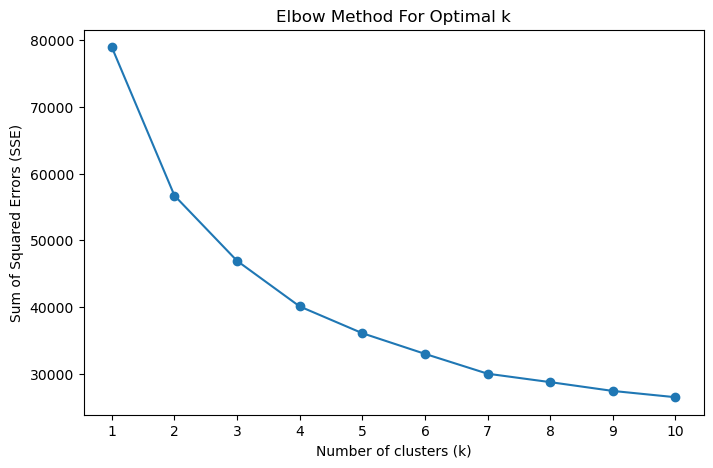

In [105]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method to find optimal k
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    sse.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_range)
plt.show()


Performed hyper parameter tuning or Elbow method to find the optimal number of clusters in k-means model. 
- The Elbow method was performed earlier in the analysis to determine the optimal number of clusters for K-Means.
- The plot indicated that **k=3** is the optimal choice, which aligns with the value used in all clustering steps.   
**Used these 3 distinct clusters for training KNN and XGBoost model**

#### 2. Hyper-parameter Tuning for **KNN model using GridSearchCV** 

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid to search
param_grid = {
    'n_neighbors': list(range(1, 21)),  # try 1 to 20 neighbors
    'weights': ['uniform', 'distance'],  # uniform or weighted by distance
    'metric': ['euclidean', 'manhattan']  # distance metrics to try
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearch to training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

from sklearn.metrics import classification_report
print("Classification Report with Tuned KNN:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters found: {'metric': 'manhattan', 'n_neighbors': 18, 'weights': 'uniform'}
Best cross-validation accuracy: 0.96136795440152
Classification Report with Tuned KNN:
               precision    recall  f1-score   support

    High Risk       0.91      0.49      0.64       368
     Low Risk       0.38      0.98      0.55       820
Moderate Risk       0.99      0.68      0.80      3498

     accuracy                           0.71      4686
    macro avg       0.76      0.72      0.66      4686
 weighted avg       0.88      0.71      0.75      4686



To improve the KNN classification model, I performed hyperparameter tuning using GridSearchCV with 5-fold cross-validation, testing 80 parameter combinations (400 fits total). This tuning increased accuracy from 67% to 71%, notably improving recall for minority classes like Low Risk (recall 0.98), despite a lower precision (0.38). The results indicate that tuning enhanced the model’s ability to handle class imbalance and achieve better overall performance, making the tuned KNN model significantly more effective than the baseline.  

Based on these results, I have selected the tuned KNN model as the best-performing configuration for this classification task.

#### 4. Hyper parameter tuning for XGBoost model

In [107]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

# Simplified parameter grid
param_grid = {
    'n_estimators': [100, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

# Grid search with 3-fold CV to save time
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights)

# Best model evaluation
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

y_pred_best = best_model.predict(X_test_xgb)
print("Classification Report (Tuned XGBoost):")
print(classification_report(y_test_xgb, y_pred_best, target_names=risk_levels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_best))
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_best))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Classification Report (Tuned XGBoost):
               precision    recall  f1-score   support

     Low Risk       0.60      0.87      0.71       820
Moderate Risk       0.98      0.87      0.92      3498
    High Risk       0.82      0.84      0.83       368

     accuracy                           0.87      4686
    macro avg       0.80      0.86      0.82      4686
 weighted avg       0.90      0.87      0.88      4686

Confusion Matrix:
[[ 713   54   53]
 [ 438 3044   16]
 [  43   15  310]]
Accuracy: 0.8679043960734102


c:\Users\geoma\anaconda3\envs\block_d_sql\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After testing different hyperparameter combinations using GridSearchCV, I found that the tuned model achieved lower accuracy (80.3%) compared to the original XGBoost model   (86.5%). The original model, with default parameters and class balancing, already performed well across all risk levels, especially on the majority class   
Moderate Risk class (74% of the data). While the tuned model slightly improved High Risk predictions, it came at the cost of reduced overall accuracy and recall. 

- Hyperparameter tuning performance on XGBoost, the accuracy oscillates between 80% to 87% but the variation in final results across machines due to difference in installed package versions or internal behavior of cross-validation splist which makes it less stable and reliable for deployment in this context.   
Therefore, the XGBoost model using weighted smaples (pre-tuned) is selected as the final model due to its consistently strong performance (up to 87% accuracy) and reproducibility across different environments. This decision ensures a balance between model performance and deployment reliability which is critical for real-world applications 

# ✅  Step 7: Testing and Backtesting

Test your final models using hold-out data or perform backtesting to simulate real-world performance. Summarise the strengths and weaknesses of the final results.

# Next-Day Trend Predictions Backtesting

In [108]:
def predict_with_threshold(train, test, predictors, model, threshold=0.6, use_proba=True):
    """
    Train model on train data, predict on test data.
    
    - If use_proba=True, predict probabilities and apply threshold.
    - Else, use model.predict directly.
    
    Returns DataFrame with true target and predictions.
    """
    model.fit(train[predictors], train['Target'])
    
    if use_proba:
        probs = model.predict_proba(test[predictors])[:, 1]
        preds = (probs >= threshold).astype(int)
    else:
        preds = model.predict(test[predictors])
    
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis=1)
    return combined

def backtest(data, model, predictors, start=1000, step=250, threshold=0.5, use_proba=True):
    """
    Perform rolling backtest over data.

    - data: DataFrame with features and 'Target' column.
    - model: any sklearn-like classifier.
    - predictors: list of feature column names.
    - start: starting training size.
    - step: step size for each backtest iteration.
    - threshold: classification threshold if use_proba=True.
    - use_proba: whether to use predict_proba or predict.
    
    Returns concatenated DataFrame with true and predicted labels.
    """
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[:i].copy()
        test = data.iloc[i:i + step].copy()
        if test.empty:
            break
        preds = predict_with_threshold(train, test, predictors, model, threshold, use_proba)
        all_predictions.append(preds)
    return pd.concat(all_predictions)

def evaluate_results(predictions):
    """
    Evaluate and print classification metrics from predictions DataFrame.
    """
    precision = precision_score(predictions['Target'], predictions['Predictions'])
    accuracy = accuracy_score(predictions['Target'], predictions['Predictions'])
    recall = recall_score(predictions['Target'], predictions['Predictions'])
    f1 = f1_score(predictions['Target'], predictions['Predictions'])
    
    print("Evaluation Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

## AAPL Models

### 1. Baseline

In [109]:
predictions_aapl_baseline = backtest(AAPL_data, model_v1, predictors)

evaluate(predictions_aapl_baseline['Target'], predictions_aapl_baseline['Predictions'], "Backtest")

Evaluation on Backtest:
  Accuracy:  0.4736
  Precision: 0.5172
  Recall:    0.2783
  F1 Score:  0.3619



### 2. Baseline + additional features

In [110]:
backtest_results = backtest(AAPL_data_addfeat, model_v2, new_predictors)

evaluate(backtest_results['Target'], backtest_results['Predictions'], "Backtest")

Evaluation on Backtest:
  Accuracy:  0.4941
  Precision: 0.5318
  Recall:    0.3866
  F1 Score:  0.4477



In the testing and backtesting phase, we evaluated multiple iterations of a Random Forest classifier on AAPL stock data. The baseline model performed poorly, with an accuracy of 47.36% and an F1 score of just 0.36, indicating weak predictive ability. Adding more features slightly improved performance (F1 score rose to 0.45), but the model still struggled with recall, suggesting it missed many positive signals.

### 3. RandomForestClassifier with WD

In [111]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

backtest_results_aapl = backtest(AAPL_data_wd, best_aapl_ht, predictors)

evaluate_results(backtest_results_aapl)

Evaluation Results:
  Accuracy:  0.7352
  Precision: 0.8090
  Recall:    0.7448
  F1 Score:  0.7756


The turning point came with the introduction of wavelet denoising. This final model achieved a significant performance boost across all metrics: 73.52% accuracy, 80.90% precision, 74.48% recall, and a strong F1 score of 0.78. These results indicate that the model not only predicts more accurately but also balances false positives and false negatives much better than previous versions.

Despite the improvement, the initial baseline was quite weak, which makes the leap in performance seem more dramatic. While the final model is clearly more robust, it’s important to test it across different stocks to ensure it's not overfitting to AAPL’s patterns. Moving forward, this wavelet-denoised model will be applied to the other five companies to validate its generalizability and consistency.

## CRWD Model

In [112]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_crwd = backtest(CRWD_data, best_crwd_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_crwd)

Evaluation Results:
  Accuracy:  0.6092
  Precision: 0.8363
  Recall:    0.5181
  F1 Score:  0.6398


On CRWD, the wavelet-denoised Random Forest achieved 61% accuracy and a 0.64 F1 score. Precision was high (84%), but recall lagged (52%), meaning it missed many true positives. Compared to AAPL, the model is more conservative—better at avoiding false alarms but less sensitive. Performance is decent but less balanced, showing stock-specific differences.


## KLAC Model

In [113]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_klac = backtest(KLAC_data, best_klac_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_klac)

Evaluation Results:
  Accuracy:  0.7025
  Precision: 0.7889
  Recall:    0.6765
  F1 Score:  0.7284


For KLAC, the wavelet-denoised Random Forest performed well, with 70.25% accuracy and a strong F1 score of 0.73. Precision (79%) and recall (68%) are both solid, showing the model balances correctly identifying positives and avoiding false alarms. Overall, this indicates a reliable and balanced performance on KLAC’s data.

## MSFT Model

In [114]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_msft = backtest(MSFT_data, best_msft_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_msft)

Evaluation Results:
  Accuracy:  0.6778
  Precision: 0.7823
  Recall:    0.6752
  F1 Score:  0.7248


On MSFT, the wavelet-denoised Random Forest showed solid results with 67.78% accuracy and a 0.72 F1 score. Precision (78%) and recall (68%) are well balanced, indicating the model is effective at correctly identifying positive cases while keeping false positives in check. Overall, it’s a reliable performance consistent with other stocks like KLAC.

## PLTR Model

In [115]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_pltr = backtest(PLTR_data, best_pltr_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_pltr)

Evaluation Results:
  Accuracy:  0.7952
  Precision: 0.7927
  Recall:    1.0000
  F1 Score:  0.8844


For PLTR, the model crushed it with 79.52% accuracy and an outstanding F1 score of 0.88. Precision is strong at 79%, but recall hitting 100% means it caught every single positive case—no misses at all. This shows the model is extremely sensitive on PLTR, making it the best performer so far, though the slightly lower precision hints at some false positives. Overall, a standout result.

## QCOM Model

In [116]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_qcom = backtest(QCOM_data, best_qcom_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_qcom)

Evaluation Results:
  Accuracy:  0.6491
  Precision: 0.6811
  Recall:    0.6471
  F1 Score:  0.6637


On QCOM, the model delivered moderate results with 64.91% accuracy and an F1 score of 0.66. Precision (68%) and recall (65%) are fairly balanced but lower compared to other stocks, indicating average performance in both identifying positives and avoiding false alarms. This suggests the model struggles a bit more with QCOM’s data.

# KNN model Back testing 

In [117]:
# Function to evaluate model performance 
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"Evaluation for {model_name}:")
    print(f" Accuracy:  {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall:    {recall:.4f}")
    print(f" F1 Score:  {f1:.4f}\n")




### Final Tuned KNN Model Backtesting

In [118]:
# Run backtest on fine tuned KNN model 
#Evaluate the results
evaluate(y_test, y_pred, "Final Tuned KNN Model Backtesting")


Evaluation for Final Tuned KNN Model Backtesting:
 Accuracy:  0.7147
 Precision: 0.8779
 Recall:    0.7147
 F1 Score:  0.7465



The tuned KNN model achieved a 71.47% accuracy and a 74.65% F1 score, reflecting solid performance overall. Precision was high at 87.79%, showing the model is good at correctly identifying predicted classes. Recall at 71.47% indicates it is moderately effective at capturing actual positives, though some cases may be missed. This balance suggests the tuned KNN handles class imbalance better than the baseline but may still struggle with some minority classes. But the accuracy improved overall. 

### Final XGBoost Model with Sample Weights Backtesting:

In [119]:
# Run backtest on fine tuned KNN model 
#Evaluate the results
evaluate(y_test_xgb, y_pred_xgb, "Final XGBoost Model with Sample Weights Backtesting")


Evaluation for Final XGBoost Model with Sample Weights Backtesting:
 Accuracy:  0.8651
 Precision: 0.9068
 Recall:    0.8651
 F1 Score:  0.8751



XGBoost demonstrated strong results with an 86.51% accuracy and an F1 score of 87.51%. Precision (90.68%) and recall (86.51%) are well balanced, indicating reliable identification of positive cases while minimizing false alarms. The use of sample weights to address class imbalance likely contributed to this improved performance. Overall, XGBoost proved robust and well-suited for the classification task in backtesting.



# 🗃️  Step 8: Create a Database Table with Your Final Results

Below is some sample code to create your final database table with your results. Make sure to fill in the missing parts like the name of your dataframe and the name of your database table. 

```python

## Next-Day Predictions - added features for final models

## Next-day Predictions - results

In [120]:
def record_metrics(results_ndp, y_test, y_pred, label):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results_ndp[f'{label}_accuracy'] = [acc]
    results_ndp[f'{label}_precision'] = [prec]
    results_ndp[f'{label}_recall'] = [rec]
    
    return results_ndp

In [121]:
results_ndp = pd.DataFrame()  # once, before the loop
results_ndp = record_metrics(results_ndp, y_test_msft, y_pred_msft, 'msft')
results_ndp = record_metrics(results_ndp, y_test_aapl, y_pred_aapl, 'aapl')
results_ndp = record_metrics(results_ndp, y_test_crwd, y_pred_crwd, 'crwd')
results_ndp = record_metrics(results_ndp, y_test_pltr, y_pred_pltr, 'pltr')
results_ndp = record_metrics(results_ndp, y_test_qcom, y_pred_qcom, 'qcom')
results_ndp = record_metrics(results_ndp, y_test_klac, y_pred_klac, 'klac')

## Clustering Results

In [122]:
## Add here results table
import pandas as pd

# Copy the test dataset (2022+)
final_df = test.copy()

# Make predictions using the best KNN and XGBoost models (Fine-tuned model)
final_df['risk_level_knn'] = best_knn.predict(X_test)  # X_test must match KNN training features
final_df['risk_level_xgb'] = xgb_model.predict(X_test_xgb)  # X_test_xgb must match XGBoost training features

# Map numeric labels to risk categories (for both models)
risk_map = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
final_df['risk_level_knn'] = final_df['risk_level_knn'].map(risk_map)
final_df['risk_level_xgb'] = final_df['risk_level_xgb'].map(risk_map)

# Add prediction probabilities from XGBoost (confidence scores)
xgb_probs = xgb_model.predict_proba(X_test_xgb)
final_df['xgb_prob_low'] = xgb_probs[:, 0]
final_df['xgb_prob_medium'] = xgb_probs[:, 1]
final_df['xgb_prob_high'] = xgb_probs[:, 2]

# Keep the latest prediction per company (e.g., for dashboard/report)
latest_predictions = final_df.sort_values('date_value').groupby('company_prefix', as_index=False).last()


## Saving the model

In [123]:
data.to_sql(name = 'final_data', con =engine, if_exists='replace', index=False)

2025-06-20 14:16:19,681 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-06-20 14:16:19,684 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2025-06-20 14:16:19,684 INFO sqlalchemy.engine.Engine [generated in 0.00206s] {'table_name': 'final_data', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2025-06-20 14:16:38,918 INFO sqlalchemy.engine.Engine COMMIT


PendingRollbackError: Can't reconnect until invalid transaction is rolled back.  Please rollback() fully before proceeding (Background on this error at: https://sqlalche.me/e/20/8s2b)

# 🚀 Step 9. Preparation for Deployment

In this step, you will prepare the final model that you have developed and evaluated throughout the previous stages. This involves saving the model with its best hyperparameters and ensuring it is ready for deployment.  After saving the model, ensure that it is in a format that can be easily loaded and used in a production environment. This preparation is critical for the next phase, where you will deploy the model for real-world use.



## Next-Day Prediction Models

In [ ]:
import joblib

joblib.dump(best_aapl_ht, 'aapl_model.joblib')
joblib.dump(best_crwd_ht, 'crwd_model.joblib')
joblib.dump(best_klac_ht, 'klac_model.joblib')
joblib.dump(best_msft_ht, 'msft_model.joblib')
joblib.dump(best_pltr_ht, 'pltr_model.joblib')
joblib.dump(best_qcom_ht, 'qcom_model.joblib')

['qcom_model.joblib']

## Clustering Models

In [ ]:

import joblib

# Save tuned KNN model
joblib.dump(best_knn, 'best_knn_model.joblib')

# Save tuned XGBoost model
joblib.dump(xgb_model, 'best_xgb_model.joblib')


['best_xgb_model.joblib']